### Hospital Readmission Prediction Using Machine Learning on the Diabetes 130-US Hospitals Dataset (1999–2008)

---

### Dataset

Diabetes 130-US Hospitals for Years 1999–2008

---

### Project Overview

Hospital readmission is a significant challenge in modern healthcare systems because frequent readmissions increase healthcare costs, place additional pressure on hospitals and may indicate that a patient's condition was not effectively managed. Predicting whether a patient is likely to be readmitted allows healthcare providers to identify high-risk patients, improve treatment planning and allocate medical resources more efficiently.

This project investigates the **Diabetes 130-US Hospitals for Years 1999–2008** dataset obtained from the **UCI Machine Learning Repository**. The objective is to develop and evaluate multiple supervised machine learning models capable of predicting patient readmission based on demographic information, hospital admission details, laboratory results, diagnoses and prescribed diabetic medications.

Throughout this notebook we will demonstrate a systematic machine learning methodology.

---

### Notebook Objectives

The primary objectives of this notebook are to:

- Understand the characteristics and quality of the dataset.
- Perform comprehensive exploratory data analysis (EDA).
- Identify and resolve data quality issues through appropriate preprocessing techniques.
- Engineer and select informative features for predictive modelling.
- Train and compare multiple supervised machine learning classification algorithms.
- Optimise model performance using appropriate hyperparameter tuning techniques.
- Evaluate model performance using multiple classification metrics.
- Identify the most suitable model for predicting hospital readmission while discussing performance, interpretability and practical applicability.

---

### Notebook Workflow

The project follows the standard machine learning workflow illustrated below.

```

Dataset Collection
↓
Exploratory Data Analysis (EDA)
↓
Data Preprocessing
↓
Feature Engineering
↓
Feature Selection
↓
Train-Test Split
↓
Model Development
↓
Hyperparameter Optimisation
↓
Model Evaluation
↓
Model Comparison
↓
Conclusion

```

Each stage of this workflow is presented with the underlying theory, implementation, experimental results and critical discussion to provide a complete understanding of the machine learning pipeline.

---

## 1. Dataset Overview

Before building any machine learning model, it is important to understand the dataset. A machine learning model learns patterns from the data, so the quality of the data has a direct impact on the quality of the predictions. If the dataset contains missing values, incorrect information or unnecessary features, the model may produce poor results.

In this section, we will introduce the dataset, explain why it was chosen, describe what information it contains and discuss how it was collected. Understanding the dataset first will help us make better decisions later during data preprocessing, feature engineering and model building.

---

### 1.1 Introduction to the Dataset

The dataset used in this project is the **Diabetes 130-US Hospitals for Years 1999–2008** dataset obtained from the **UCI Machine Learning Repository**.

The dataset contains **101,766 inpatient hospital encounters** collected from **130 hospitals and integrated healthcare delivery networks** across the United States between **1999 and 2008**.

Each row in the dataset represents **one hospital encounter**, not one patient. This means that the same patient may appear more than once if they were admitted to the hospital multiple times during the ten-year period. Each column contains information describing that hospital encounter, such as the patient's age, diagnosis, medications, laboratory test results and previous hospital visits.

The goal of this project is to use this information to predict whether a patient will be readmitted to the hospital after discharge.

---

### 1.2 Why was this dataset collected?

To make sure the data represented meaningful hospital admissions, only encounters that satisfied the following conditions were included:

1. The encounter was an **inpatient hospital admission**.
2. The patient had **diabetes recorded as one of the diagnoses**.
3. The patient stayed in the hospital for **at least one day but no more than fourteen days**.
4. **Laboratory test** was performed during the hospital stay.
5. **Medication** was given during the hospital encounter.

These conditions ensure that every record contains enough clinical information to support meaningful analysis and machine learning.

---

### 1.3 Why was this dataset selected?

The Diabetes 130-US Hospitals dataset was chosen for several reasons.

- It addresses a real-world healthcare problem with practical importance.
- It contains **101,766 hospital encounters**, providing enough data to train and evaluate machine learning models.
- It includes information from **130 hospitals** collected over a **10-year period (1999–2008)**, making it a large and diverse healthcare dataset.
- It contains both numerical and categorical features, allowing different preprocessing and encoding techniques to be demonstrated.
- It includes real-world data challenges such as missing values, high-cardinality categorical variables and class imbalance, making it suitable for demonstrating data preprocessing and feature engineering.
- It contains demographic, clinical, laboratory and medication information, allowing many different factors that may influence hospital readmission to be analysed.
- It is a well-known public dataset that has been widely used in healthcare and machine learning research, making it suitable for comparison with previous studies.

- Overall, this dataset provides an excellent opportunity to demonstrate the complete machine learning workflow, from understanding the data and preparing it for analysis to building, optimising and evaluating multiple machine learning models.
---

### 1.4 What information does the dataset contain?

The dataset contains more than fifty features describing different aspects of a patient's hospital encounter. Instead of looking at every feature individually, it is easier to group similar features together.

### Demographic Information

These features describe the patient.

Examples include:

- Race
- Gender
- Age
- Weight

These features provide background information about each patient and may influence hospital readmission.

### Hospital Admission Information

These features describe the patient's hospital stay.

Examples include:

- Admission type
- Admission source
- Discharge disposition
- Time spent in hospital

These features describe how the patient entered the hospital, how long they stayed and how they were discharged.

### Clinical Information

These features describe the patient's medical condition.

Examples include:

- Primary diagnosis
- Secondary diagnoses
- Number of diagnoses
- Medical specialty

These features help describe the patient's overall health and medical history.

### Laboratory Information

These features describe laboratory tests performed during the hospital stay.

Examples include:

- HbA1c test result
- Serum glucose result
- Number of laboratory procedures

Laboratory test results provide useful information about the patient's condition during admission.

### Medication Information

The dataset also contains several features describing diabetes medications.

These features record whether a medication was prescribed and whether the dosage was increased, decreased or kept the same during the hospital stay.

Medication information may provide useful clues about the patient's treatment and disease management.

### Previous Healthcare Utilisation

These features describe how often the patient used healthcare services before the current hospital admission.

Examples include:

- Number of outpatient visits
- Number of emergency visits
- Number of inpatient visits

 These features describe the patient's use of healthcare services during the year before the current hospital admission. A patient's previous healthcare utilisation may provide useful information about their health status and may help machine learning models predict the risk of future hospital readmission.
 
---

### 1.5 What will we do next?

Now that we understand the background of the dataset, the next step is to load it into Python and explore its structure.

We will examine:

- the number of rows and columns,
- the data types of each feature,
- missing values,
- summary statistics,
- and the target variable.

This will help us understand the quality of the data and decide what preprocessing steps are required before building machine learning models.

---

### Load csv from file

Read a CSV file from your local system. 

The `.read_csv()` function returns a `pandas.DataFrame` object, which is a powerful 2D data structure that allows row and column operations, descriptive statistics, and data manipulations. 

---


In [ ]:
# Install required libraries
%pip install pandas


In [128]:
import pandas as pd

# ============================================================
# Load the Diabetes Dataset
# ============================================================
filename = "diabetic_data.csv"

# Read the dataset while preserving valid category values
# such as "None". This prevents pandas from automatically
# converting them into missing values (NaN).

df = pd.read_csv(
    filename,
    keep_default_na=False
)

### Checking the Dataset

*After loading a dataset, it is good practice to inspect the first few rows before performing any analysis. This helps confirm that the dataset has been loaded correctly and provides a quick overview of its structure.*

*The `head()` function displays the first five rows of a DataFrame by default. It is commonly used to verify that the column names have been read correctly and that the values appear under the correct features.*

We will now display the first five rows of the dataset to confirm that the data has been loaded successfully.

---

In [129]:
# ============================================================
# Display the First Five Rows
# ============================================================

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Understanding the Output

The output displays the first five hospital encounters in the dataset.

From these rows, we can make a few initial observations.

- Each row represents one hospital encounter.
- Each column represents one feature describing that encounter.
- The dataset contains a mixture of numerical and categorical features.
- The column names appear to have been loaded correctly.
- The dataset appears to have been imported successfully.

At this stage, we are only confirming that the dataset has been loaded correctly. A detailed exploration of the data will be carried out in the upcoming sections.

---

### 1.6 Exploring the Dataset

### What is the dimensionality of our data?

Before we start analysing or training a model, it's helpful to know the *shape* of the dataset, that is, how many rows and columns it contains. This gives us a sense of how big the dataset is and what we're working with.

We can check this using the `.shape` attribute in a pandas DataFrame, which returns a result like this:

```
(rows, columns)
```

- The number of *rows* tells us how many *examples* or *participants* are in the dataset.  
- The number of *columns* tells us how many *features* (measurements) we have for each example. 

Example:

- Each **row** represents one hospital encounter.
- Each **column** represents one feature describing that encounter.

Understanding the dataset's shape helps us:
- Plan how to split the data into training and testing sets  
- Estimate how much memory we'll need  
- Choose models and techniques that are suitable for the size of the data  


In [130]:
# How big is our data
print(df.shape)

(101766, 50)



This knowledge helps us ensure we have the complete dataset loaded. It's also a good initial check before we proceed to more in-depth data profiling or feature analysis.

The output is:

```
(101766, 50)
```

It means:

- The dataset contains **101,766 hospital encounters**.
- Each encounter is described using **50 features**.

---

### Exploring more details of the data

Beyond checking the first few and last few rows, pandas offers convenient methods to quickly summarise your dataset. For instance, if you want to view column data types and any non-null counts, you can use `data.info()`. This can be useful to spot missing values or confirm that columns are numeric:

In [131]:
# Checking data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

From `data.info()`, we get a quick overview of the dataset's structure. It tells us:

- How many rows are in the dataset  
- Which columns are present  
- How many non-null (non-missing) values are in each column  
- What data type each column uses (such as `int64` for whole numbers, `float64` for decimal numbers, or `object` for text)

This information is especially helpful for spotting issues early. For example:
- If a column has fewer non-null values than the total number of rows, it likely contains *missing data*.
- If a column that should contain numbers is listed as `object`, the values might be stored as text, possibly due to formatting issues (like commas or symbols).

Checking the results of `data.info()`, allows us to make sure the dataset is properly formatted and ready for analysis or model training.

---

### 1.7 Analysing , visualising and Transforming tabular data

### Introduction  

We will explore how to analyse and preprocess a numeric/tabular dataset to gain meaningful insights before applying machine learning models. Understanding your data is a crucial first step in any data science workflow, as it influences how well your models perform and generalise to unseen data.

We will cover three key aspects of data exploration and preparation:  

- *Describing the dataset*: we will generate statistical summaries, such as measures of central tendency (mean, median) and dispersion (variance, standard deviation), to understand the distribution of each feature. Additionally, we will examine missing values, outliers, and correlations between variables to identify patterns and potential preprocessing steps.  

- *Visualising the dataset*: data visualisation helps us uncover hidden relationships, trends, and anomalies. We will use histograms, box plots, scatter plots, and correlation heatmaps to visually inspect distributions, detect skewness, and understand feature interactions.    
**Visualisations will be introduced throughout the notebook whenever they help explain the data. This approach ensures that each visualisation has a clear purpose rather than being included unnecessarily.**

This process is essential for making informed decisions in machine learning, as the quality of your input data directly impacts model accuracy and reliability.

### Describing the Dataset

#### Statistical summary

Descriptive statistics help us understand how each part of a dataset is spread out. When we run `.describe()` on a pandas DataFrame in Python, we get a helpful summary that includes:

- *Count*:  </br>
Tells us how many values are present (not missing) for each column. This helps us spot any gaps in the data.

- *Mean*:  </br>
The average value. This gives us a rough idea of what's "typical" for each column.

- *Standard Deviation*:</br>
Shows how much the values vary. A high number means the data is more spread out.

- *Minimum Value*:  </br>
The smallest number in the column. This can help us find any errors or outliers.

- *25th Percentile (Q1)*:  </br>
A quarter of the values fall below this point. It gives us a sense of the lower end of the data.

- *50th Percentile (Median/Q2)*:  </br>
The middle value when the data is sorted. This shows us the centre of the data.

- *75th Percentile (Q3)*:  </br>
Three-quarters of the data fall below this point. It helps us understand the upper range.

- *Maximum Value*:  </br>
The largest value in the column. This can highlight extreme values or mistakes.

These summaries make it easier to spot missing information, unusual results, or parts of the data that might need special attention, like features with a very wide range of values:


In [132]:
# Summary Statistics 
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


To explore the categorical features in the Diabetes Hospital Readmission dataset, we use the `describe()` function with the parameter `include=["object"]`. This tells pandas to generate summary statistics only for columns stored as the **object** data type, which in this dataset represents the categorical features.

The output of `describe()` is displayed using **`.T` (transpose)**, which swaps the rows and columns of the table. This does not change the data itself; it simply makes the output easier to read by displaying one feature per row.


In [133]:
# Summary Statistics for Categorical Features
df.describe(include=["object"]).T

/var/folders/6w/6jhfgq8s7hb_9__z7h3g3tcm0000gn/T/ipykernel_68813/4028559741.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"]).T


,count,unique,top,freq
race,101766,6,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
weight,101766,10,?,98569
payer_code,101766,18,?,40256
medical_specialty,101766,73,?,49949
diag_1,101766,717,428,6862
diag_2,101766,749,276,6752
diag_3,101766,790,250,11555
max_glu_serum,101766,4,None,96420


### Understanding the Output

Unlike numerical features, categorical features are summarised using different statistics because they represent labels or categories rather than continuous numerical values.

The output includes:

- **Count** – The number of values that are **not recognised by pandas as missing**.
- **Unique** – The number of distinct categories present in the feature.
- **Top** – The most frequently occurring category (mode).
- **Freq** – The number of times the most common category appears.

These statistics provide a quick overview of the categorical features and help us understand the distribution of different categories before performing data preprocessing or feature engineering.

An important point to note is that these statistics may not always represent the true characteristics of the data. In this dataset, some missing information is stored using placeholder values such as `?` . Since pandas treats `?` as ordinary text, these placeholder values are included in the calculated statistics. As a result, the **Count**, **Unique**, **Top** and **Freq** values may be affected.

For this reason, a dedicated missing value analysis will be performed later in the notebook.

---

## 2. Data Quality Assessment

*Before building any machine learning model, it is essential to assess the quality of the dataset. A machine learning model learns patterns directly from the data it is given. Therefore, if the dataset contains missing values, incorrect data, duplicate records or inconsistent formatting, these problems can negatively affect the model's performance and reduce its ability to make accurate predictions on unseen data.*

*Data Quality Assessment is the process of examining the dataset to identify issues that may need to be addressed before further analysis or model training. Detecting these problems early allows appropriate preprocessing techniques to be applied and helps ensure that the final dataset is suitable for machine learning.*

*The main aspects of data quality assessment include:*

- *Identifying missing values.*
- *Detecting duplicate records.*
- *Checking data types and feature consistency.*
- *Identifying placeholder values.*
- *Assessing whether any features contain too little useful information.*

For the Diabetes Hospital Readmission dataset, this stage is particularly important because several features are known to contain missing information represented by placeholder values such as `?`. As a result, these issues are not immediately detected by functions such as `info()` or `describe()` and require further investigation.

---

### What will we examine?

To assess the quality of the dataset, we will investigate several important aspects of the data.

1. **Missing Value Analysis**  
   Identify features containing missing information and determine how much data is missing.

2. **Duplicate Record Analysis**  
   Check whether duplicate hospital encounters exist within the dataset.

3. **Data Type Verification**  
   Verify that each feature has an appropriate data type and identify any features that may require conversion during preprocessing.

4. **Feature Quality Assessment**  
   Examine individual features to identify those that contain very little useful information, a large number of unique categories or other characteristics that may influence preprocessing decisions.

The outcome of this assessment will determine how the dataset is cleaned and prepared before feature engineering, feature selection and machine learning model development.

---

### Missing Value Analysis

*Missing values are one of the most common data quality problems encountered in real-world datasets. They can reduce the amount of information available to a machine learning model and may negatively affect prediction performance if they are not handled appropriately.*

*It is important to identify which features contain missing information and determine the extent of the missing data. This helps us make informed preprocessing decisions rather than making assumptions about the quality of the dataset.*

*In many real-world datasets, placeholder values such as `?` are used as an actual missing value. Since pandas treats these placeholders as ordinary text, they must first be converted into proper missing values before further analysis can be performed.*

In this section, we will first convert placeholder values into missing values recognised by pandas. We will then calculate the number and percentage of missing values for each feature to identify columns that may require further preprocessing.

---

In [134]:
# ============================================================
# Convert Placeholder Values to Missing Values
# ============================================================

# The Diabetes dataset uses '?' to represent missing information.
# Pandas treats '?' as ordinary text rather than a missing value.
# Replace every '?' with pd.NA so that pandas recognises it as missing.

df.replace("?", pd.NA, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


### Calculating Missing Values

*After converting placeholder values into missing values recognised by pandas, the next step is to measure the extent of missing data within the dataset.*

*Missing value analysis helps identify which features contain incomplete information and how much data is missing from each feature. This information is important because different levels of missing data may require different preprocessing strategies.*

*Both the number of missing values and the percentage of missing values are calculated. To show a better indication of the overall severity of missing data relative to the size of the dataset.*

The results will be combined into a single summary table and sorted from the highest percentage of missing values to the lowest. This makes it easier to identify the features that require the greatest attention during data preprocessing.

---

In [135]:
# ============================================================
# Count Missing Values
# ============================================================

# Count the number of missing values in each feature.
# isnull() identifies missing values (NaN / pd.NA).
# sum() adds the True values to calculate the total number
# of missing values for every column.

missing_count = df.isnull().sum()

# ============================================================
# Calculate Missing Value Percentage
# ============================================================

# Calculate the percentage of missing values for each feature.
# Divide the missing value count by the total number of rows
# and multiply by 100.

missing_percentage = ((missing_count / len(df)) * 100).round(2)

# ============================================================
# Create Missing Value Summary Table
# ============================================================

# Create a summary table containing both the number and
# percentage of missing values for each feature.

missing_summary = pd.DataFrame({

    "Missing Count": missing_count,

    "Missing Percentage (%)":
        missing_percentage

})

# Sort the table so that the features with the highest
# percentage of missing values appear first.

missing_summary = missing_summary.sort_values(
    by="Missing Percentage (%)",
    ascending=False
)

# Display the missing value summary.

missing_summary

,Missing Count,Missing Percentage (%)
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00
tolazamide,0,0.00
glyburide,0,0.00


### Observations

The missing value summary shows that most features in the dataset are complete and contain no missing values. Only a small number of features contain missing information, although the amount of missing data varies considerably between them.

At this stage, no preprocessing decisions are made. The missing value analysis is used to understand the quality of the dataset and will guide the preprocessing decisions in the following sections.

### 2.2 Duplicate Record Analysis

*Duplicate records occur when exactly the same observation appears more than once in a dataset. Identifying duplicate records is an important part of data quality assessment because duplicated observations can introduce bias into statistical analysis and machine learning models.*

*In this section, the dataset will be examined to determine whether any completely identical rows exist. If duplicate records are found, they will be investigated before deciding whether they should be removed.*

---

In [136]:
# ============================================================
# Check for Duplicate Records
# ============================================================

# Count the number of duplicate rows in the dataset.
# duplicated() identifies rows that are exact copies of
# previous rows.
# sum() counts the total number of duplicate records.

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


### Observations

No duplicate records were identified in the dataset. This indicates that each hospital encounter is unique and no duplicate rows require removal before further preprocessing.

It is important to note that this does not mean every patient appears only once. Since each row represents a hospital encounter, the same patient may appear multiple times if they were admitted to hospital on different occasions.

---

### 2.3 Initial Feature Assessment

*Not every feature contained within a dataset is necessarily useful for machine learning. Some variables exist only to uniquely identify observations, while others may contain little predictive information or present significant data quality issues.*

*Before performing data preprocessing, it is useful to examine the purpose of some features . Removing unnecessary features reduces model complexity, decreases computational cost and prevents algorithms from learning patterns from information that is unrelated to the prediction task.*

*At this stage, features are assessed based on their meaning, their role within the dataset and the results of the previous data quality assessment. Final preprocessing decisions will then be made before preparing the dataset for machine learning.*

Feature: `encounter_id`

Unique identifier of  each hospital encounter within the dataset. It serves only as an  identifier and does not describe the patient's health condition, treatment or likelihood of hospital readmission, it is unlikely to provide useful predictive information for machine learning.Therefore, this feature is considered a candidate for removal during preprocessing.


Feature: `patient_nbr`

Uniquely identifies individual patients. Same patient may appear multiple times because each row represents a separate hospital encounter, this feature represents patient identity rather than clinical characteristics. Furthermore, the dataset already contains features such as `number_outpatient`, `number_emergency` and `number_inpatient`, which summarise the patient's previous healthcare utilisation without revealing their identity. Therefore, this feature is also considered a candidate for removal before model training.


Feature: `weight`

The `weight` feature contains 96.86% missing values, making it the feature with the largest amount of missing information in the dataset. Such a high proportion of missing data leaves very little usable information for model training and would make reliable imputation difficult. Therefore, `weight` is considered a strong candidate for removal during preprocessing.


Feature: `payer_code`

The `payer_code` feature contains approximately 39.56% missing values. Although this is considerably lower than the `weight` feature, a substantial proportion of the information is still unavailable. As this variable primarily records Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay. Therefore, this feature is identified for further investigation before making a preprocessing decision.


Feature: `medical_specialty`

The `medical_specialty` feature contains approximately 49.08% missing values. Despite this, it may still provide clinically useful information because it records Integer identifier of a specialty of the admitting physician. This feature will also be investigated further before deciding how it should be handled during preprocessing.

### Summary

The initial feature assessment focused only on the features that required immediate attention because they either act as identifiers or contain a substantial proportion of missing values.

The remaining features were not included in this discussion, this does not necessarily mean they will all be retained without modification. Many of these features, particularly the categorical variables and medication-related attributes, will require further preprocessing, including missing value treatment, category encoding and data transformation.

Therefore, the assessment presented in this section should be considered an initial evaluation rather than a complete review of every feature. The remaining features will be examined individually during the subsequent preprocessing stages as required.

---

## 3. Data Preprocessing

*The previous section focused on understanding the quality and characteristics of the dataset. Based on these findings, the dataset can now be prepared for machine learning.*

*Data preprocessing involves modifying the dataset so that it is suitable for training machine learning models. This includes removing unnecessary features, handling missing values, transforming categorical variables and preparing numerical features for analysis.*

*The preprocessing steps are performed in a logical sequence so that each decision is supported by the results of the previous data quality assessment.*

---

### 3.1 Feature Removal

*The initial feature assessment identified features that are unlikely to contribute useful information for predicting hospital readmission. Removing these features before performing other preprocessing tasks simplifies the dataset and avoids unnecessary processing of variables that will not be used during model training.*

*Each removal decision is based on the purpose of the feature and the observations made during the data quality assessment.*

`Features Selected for Removal`

Based on the data quality assessment and the initial feature assessment, three features have been identified for removal before further preprocessing.

`encounter_id`
Since it provides no meaningful predictive information, this feature will be removed.

`patient_nbr`
Previous healthcare utilisation is already represented by other variables in the dataset, making this identifier unnecessary for prediction. Therefore, this feature will be removed.

`weight`
Contains approximately 96.86% missing values, meaning that weight information is unavailable for most hospital encounters. With such a large proportion of missing data, the feature provides very little useful information for model training and reliable imputation would be difficult. Therefore, this feature will be removed.

Features such as `payer_code` and `medical_specialty` require further investigation because they contain useful information despite having missing values. 

Other categorical and numerical features will also undergo additional preprocessing before they are used for machine learning.

In [137]:
# ============================================================
# Remove Unnecessary Features
# ============================================================

# Remove features that were identified as unsuitable
# for machine learning during the feature assessment.

df = df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "weight"
    ]
)

# Display the updated dataset dimensions.

print("Updated dataset shape:", df.shape)

Updated dataset shape: (101766, 47)


*Following the feature removal, remaining missing values must be addressed before the dataset can be used for machine learning.*

*Missing values should not all be handled using the same technique. The most appropriate treatment depends on the proportion of missing values, the purpose of the feature and the potential impact on model performance.*

*In this section, each remaining feature containing missing values will be examined individually. Based on its characteristics, an appropriate preprocessing strategy will be selected before any modifications are applied to the dataset.*

Feature: `payer_code`

The `payer_code` feature records the patient's payment or insurance category for the hospital encounter. It does not directly describe the patient's clinical condition.

Approximately **39.56%** of the values are missing, indicating that a substantial proportion of the information is unavailable. Retaining this feature would require replacing a large number of missing values which is likely to be less relevant than clinical variables such as diagnoses, laboratory results and medications.

For these reasons, the `payer_code` feature will be removed before model training.

### Features Retained for Further Preprocessing

The following features were retained because they contain potentially useful clinical or demographic information for predicting hospital readmission. Although some contain missing values, the amount of missing data is either relatively small or the feature is considered sufficiently informative to justify further preprocessing rather than removal.

Feature: `medical_specialty`

The `medical_specialty` feature records the specialty of the physician responsible for the patient's care. Unlike administrative variables, this feature may contain clinically relevant information because patients treated by different medical specialties may have different risks of hospital readmission. Although approximately **49.08%** of the values are missing, removing the entire feature would result in the loss of potentially valuable information.

Feature: `race`

The `race` feature records the patient's reported racial group and contains only **2.23%** missing values. Since the proportion of missing data is relatively small and the feature may still provide useful demographic information.

Features: `diag_1`, `diag_2` and `diag_3`

These features record the patient's primary, secondary and additional secondary diagnoses respectively. These diagnosis codes provide important clinical information that may help predict hospital readmission.

Only a very small proportion of values are missing (`diag_1`: **0.02%**, `diag_2`: **0.35%**, and `diag_3`: **1.40%**). Removing these features or deleting the affected hospital encounters would result in an unnecessary loss of valuable clinical information.

---


### Features Requiring Special Consideration

In addition to the features discussed above, two laboratory test features require special consideration.
Unlike the previous features, they do not contain missing values. Instead, they contain the valid category **`none`**, which indicates that the corresponding laboratory test was **not performed** rather than representing missing information.

These features are examined separately below to ensure that the category **`none`** is interpreted correctly during preprocessing.

Feature: `max_glu_serum`

The `max_glu_serum` feature records the patient's maximum serum glucose test result. The feature contains four possible categories including **`none`**, where `none` indicates that the laboratory test was not performed rather than representing missing information.

Feature: `A1Cresult`

The `A1Cresult` feature records the patient's HbA1c laboratory test result. Similar to `max_glu_serum`, the category **`none`** indicates that the laboratory test was not performed rather than representing missing information.

Since all categories contain meaningful information, no missing value treatment is required for both features. Theese features will therefore be retained without modification during this preprocessing step.

---

In [138]:
# ============================================================
# Remove payer_code
# ============================================================

# Remove the payer_code feature because it contains a large
# proportion of missing values and provides administrative
# rather than clinical information.

df = df.drop(columns=["payer_code"], errors="ignore")

# Display remaining missing values.

print(df.isnull().sum())

# Display the updated dataset dimensions.

print("Updated dataset shape:", df.shape)

race                         2273
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone  

###  Missing Value Handling

*The preprocessing decisions made in the previous section are now applied to the dataset.*

*For the retained categorical features, genuine missing values are replaced with the category **"Unknown"** rather than removing observations from the dataset. This preserves all hospital encounters while clearly distinguishing unavailable information from the original recorded categories.*

*The laboratory test features `max_glu_serum` and `A1Cresult` are excluded from this step because the category `None` represents a valid laboratory outcome indicating that the test was not performed rather than missing information.*

---

In [139]:
# ============================================================
# Handle Remaining Missing Values
# ============================================================

# Replace missing values in the retained categorical features
# with the category "Unknown". This preserves all hospital
# encounters while explicitly indicating that the original
# information was unavailable.

df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")

df["race"] = df["race"].fillna("Unknown")

df["diag_1"] = df["diag_1"].fillna("Unknown")

df["diag_2"] = df["diag_2"].fillna("Unknown")

df["diag_3"] = df["diag_3"].fillna("Unknown")


# ============================================================
# Verify Missing Values
# ============================================================

# Display the remaining number of missing values
# for each feature.

print(df.isnull().sum())

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

### Observations

The selected missing value treatments were successfully applied to the dataset.

Missing values in `medical_specialty`, `race`, `diag_1`, `diag_2` and `diag_3` were replaced with the category **"Unknown"**, allowing every hospital encounter to be retained without introducing artificial estimates.

Following these preprocessing steps, the dataset no longer contains missing values and is ready for the next stage of preprocessing.

---

###  Constant Feature Assessment

*Before transforming categorical variables, it is useful to identify features that contain only a single unique value across the entire dataset.*

*A feature with no variation provides the same information for every hospital encounter.  Features containing only one unique category might not contribute useful predictive information.*

*The dataset will therefore be examined to identify any constant features before categorical feature transformation.*

If a feature contains only one unique value, it is identified as a constant feature and added to a list for further inspection.

The names of all constant features are displayed.

---

In [140]:
# ============================================================
# Identify Constant Features
# ============================================================

# Create an empty list to store the names of
# features containing only one unique value.

constant_features = []

# Examine every feature in the dataset.

for column in df.columns:

    # Count the number of distinct values.
    unique_values = df[column].nunique()

    # If only one unique value exists,
    # store the feature name.

    if unique_values == 1:
        constant_features.append(column)

# Display all constant features.

print("Constant Features:")
print(constant_features)

Constant Features:
['examide', 'citoglipton']


In [141]:
# =================================================
# Remove Constant Features
# =================================================

# Remove features containing only one unique value.

df = df.drop(columns=constant_features)

# Display the updated dataset dimensions.

print("Updated dataset shape:", df.shape)

Updated dataset shape: (101766, 44)


### Observation

Two features were identified as constant features:

- `examide`
- `citoglipton`

Although both medication features are defined with four possible categories (`No`, `Steady`, `Up` and `Down`), only the category `No` is present in this dataset. This indicates that these medications were not prescribed during any of the recorded hospital encounters.

As a result, these features contain no variation and are not provide useful information for our predictions, both features will be removed before further preprocessing.

---

### 3.2 Categorical Feature Transformation

*Following data cleaning, the remaining categorical features must be transformed into numerical representations before they can be used by most machine learning algorithms.*

*Different categorical features have different characteristics. Some contain a natural ordering between categories, while others represent unrelated groups or contain a large number of unique values. Consequently, no single encoding technique is appropriate for every feature.*

*Each feature in this project will be examined individually before selecting the most appropriate encoding strategy.*

*For each categorical feature, the following questions will be considered:*

1. *What does the feature represent?*
2. *Does it contain a natural ordering between categories?*
3. *How many distinct categories does it contain?*
4. *Which encoding method best preserves its information while avoiding unnecessary complexity?*

*Only after answering these questions will the selected encoding method be applied.*

---

### Feature Groups

The categorical features within the dataset describe different aspects of each hospital encounter. Although all of these variables are categorical, they do not all require the same preprocessing strategy.

To simplify the preprocessing pipeline, features with appears to have similar meanings, have been grouped together where appropriate. Each `feature or feature group` will then be examined to determine the most suitable preprocessing and encoding strategy. Features with unique characteristics will continue to be analysed individually.

The categorical features have been organised into the following groups:

| Group | Features |
|-------|----------|
| Demographic Features | `race`, `gender`, `age` |
| Admission Information | `admission_type_id`, `discharge_disposition_id`, `admission_source_id` |
| Diagnosis Features | `diag_1`, `diag_2`, `diag_3` |
| Laboratory Test Features | `max_glu_serum`, `A1Cresult` |
| Medication Features | All remaining diabetes medication variables (`metformin` to `metformin-pioglitazone`) |
| Treatment Summary | `change`, `diabetesMed` |
| Physician Specialty | `medical_specialty` |
| Target Variable | `readmitted` |

The following sections examine each feature or feature group individually before selecting the most appropriate encoding method.

---

### Group 1: Demographic Features

The demographic features describe characteristics of the patient rather than their medical condition or treatment. They differ in the type of information they contain and therefore require separate consideration before selecting an encoding strategy.


#### Feature: `age`

The `age` feature records the patient's age as ten-year intervals, ranging from **`[0-10)`** to **`[90-100)`**.

These categories have a clear natural ordering because each age group represents an increase in age. Therefore, the relationship between consecutive categories is meaningful and should be preserved during preprocessing.

**Ordinal Encoding** which assigns increasing numerical values while preserving the natural progression of the age groups can be applied to this feature.

The `age` feature represents grouped age intervals rather than unrelated categories. Since the exact age of each patient is unavailable, each interval is represented by its midpoint (for example, `[20-30)` is replaced with `25`).

Using the midpoint preserves the natural ordering of the age groups while providing a closer numerical approximation to the patient's age than simply assigning consecutive integers.

---

The following code creates a mapping between each age interval and its corresponding midpoint.

The `map()` function then replaces every age category with its predefined midpoint, converting the categorical age groups into numerical values while preserving their natural ordering.

Finally, the first few transformed values are displayed to verify that the encoding has been applied correctly.

---

In [142]:
# ====================================================
# Encode Age Feature
# ====================================================

# Replace each age interval with its midpoint.
# This preserves the natural ordering while providing
# an approximate numerical representation of age.

age_mapping = {

    "[0-10)"   : 5,
    "[10-20)"  : 15,
    "[20-30)"  : 25,
    "[30-40)"  : 35,
    "[40-50)"  : 45,
    "[50-60)"  : 55,
    "[60-70)"  : 65,
    "[70-80)"  : 75,
    "[80-90)"  : 85,
    "[90-100)" : 95

}

# Replace each age category with its midpoint.
df["age"] = df["age"].map(age_mapping)

# Display the first few encoded values.
df["age"].head()

0     5
1    15
2    25
3    35
4    45
Name: age, dtype: int64

### Feature: `race`

The `race` feature records the patient's reported racial group. The possible categories are:

- Caucasian
- AfricanAmerican
- Asian
- Hispanic
- Other
- Unknown

Unlike the `age` feature, these categories do **not** have a natural ordering. For example, there is no meaningful relationship that places one racial group above or below another. Therefore, the encoding method should preserve the individual categories without introducing an artificial ranking.

- **One-Hot Encoding** creates a separate binary feature for each category, allowing every racial group to be represented independently.

Since the `race` feature is a nominal categorical variable with no natural ordering, **One-Hot Encoding** is the most appropriate approach. This preserves all categories without introducing artificial numerical relationships between them.

---

#### Feature Exploration: `gender`

The `gender` feature records the patient's reported gender. Before selecting an encoding strategy, the feature is examined to identify the available categories and determine whether any values require preprocessing.

---

In [143]:
# ============================================================
# Explore Gender Feature
# ============================================================

# Count the number of hospital encounters in each
# gender category.
gender_counts = df["gender"].value_counts(dropna=False)

# Calculate the percentage represented by each category.
gender_percent = (
    gender_counts / len(df) * 100
).round(3)

# Combine the counts and percentages into a single table.
gender_summary = pd.DataFrame({
    "Count": gender_counts,
    "Percentage (%)": gender_percent
})
print(gender_summary)

                 Count  Percentage (%)
gender                                
Female           54708          53.759
Male             47055          46.238
Unknown/Invalid      3           0.003


The `gender` feature records the patient's reported gender and contains three categories: `Female`, `Male`, and `Unknown/Invalid`.

The `Female` and `Male` categories represent valid demographic information, while `Unknown/Invalid` occurs in only **3 hospital encounters (0.003% of the dataset)**. This value indicates incomplete or invalid data rather than a meaningful gender category.

Removing these records results in a negligible loss of data while avoiding the introduction of an additional category that provides little useful information for model training.

After removing these records, the remaining `gender` feature consists of two categories (`Female` and `Male`), making it suitable for binary encoding.

---

In [144]:
# ============================================================
# Remove Invalid Gender Records
# ============================================================

# Remove hospital encounters where the gender is recorded
# as "Unknown/Invalid".
#
# These records represent incomplete demographic
# information rather than a meaningful gender category.
df = df[df["gender"] != "Unknown/Invalid"].copy()

# Verify that the invalid category has been removed.
gender_counts = df["gender"].value_counts(dropna=False)

# Calculate the percentage of each remaining category.
gender_percent = (
    gender_counts / len(df) * 100
).round(3)

# Create a summary table.
gender_summary = pd.DataFrame({
    "Count": gender_counts,
    "Percentage (%)": gender_percent
})

# Display the updated summary.
display(gender_summary)

# Display the updated dataset shape.
print("\nDataset Shape:", df.shape)

,Count,Percentage (%)
gender,,
Female,54708,53.76
Male,47055,46.24



Dataset Shape: (101763, 44)


### Encoding Strategy

The `gender` feature is a binary nominal categorical variable. Although it contains only two categories, the values represent category labels rather than numerical measurements.

To maintain a consistent preprocessing pipeline, the `gender` feature will be onde hot encoded after the train-test split together with the remaining categorical features. Performing the encoding after the split ensures that the preprocessing pipeline is fitted only on the training data before being applied to the test data, following standard machine learning practice.

### Group 2: Admission Information

The admission information features describe how a patient entered the hospital and how the hospital encounter ended. Although these features are stored as numerical identifiers, but the values represent categories.

Consequently, the numerical values should not be interpreted as having a natural ordering. 

The admission information features include:

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`

Each feature will be analysed individually before deciding how it should be transformed for machine learning.

---

### Category Distribution

Before selecting an encoding strategy, the distribution of each admission information feature is examined.

For each feature, the following information is considered:

- the number of unique categories,
- the frequency of each category, and
- the proportion of observations represented by each category.

This analysis helps determine whether categories should be retained, grouped, or removed before encoding.

In [145]:
# ============================================================
# Load Mapping Files
# ============================================================

admission_type_mapping = pd.read_csv(
    "admission_type_id_mapping.csv",
    keep_default_na=False
)

discharge_disposition_mapping = pd.read_csv(
    "discharge_disposition_id_mapping.csv",
    keep_default_na=False
)

admission_source_mapping = pd.read_csv(
    "admission_source_id_mapping.csv",
    keep_default_na=False
)

In [146]:
# ============================================================
# Display Category Summary (a helper function)
# ============================================================

def category_summary(df, column, mapping_df):

    summary = (
        df[column]
        .value_counts()
        .sort_index()
        .rename_axis(column)
        .reset_index(name="Count")
    )

    summary["Percentage (%)"] = (
        summary["Count"] / len(df) * 100
    ).round(2)

    summary = summary.merge(
        mapping_df,
        on=column,
        how="left"
    )

    return summary[
        [column, "description", "Count", "Percentage (%)"]
    ]

In [147]:
# ============================================================
# Category Distribution of Admission Information Features
# ============================================================

print("=" * 60)
print("Admission Type")
print("=" * 60)

display(
    category_summary(
        df,
        "admission_type_id",
        admission_type_mapping
    )
)

print()

print("=" * 60)
print("Discharge Disposition")
print("=" * 60)

display(
    category_summary(
        df,
        "discharge_disposition_id",
        discharge_disposition_mapping
    )
)

print()

print("=" * 60)
print("Admission Source")
print("=" * 60)

display(
    category_summary(
        df,
        "admission_source_id",
        admission_source_mapping
    )
)

Admission Type


,admission_type_id,description,Count,Percentage (%)
0,1,Emergency,53988,53.05
1,2,Urgent,18480,18.16
2,3,Elective,18868,18.54
3,4,Newborn,10,0.01
4,5,Not Available,4785,4.70
5,6,NULL,5291,5.20
6,7,Trauma Center,21,0.02
7,8,Not Mapped,320,0.31



Discharge Disposition


,discharge_disposition_id,description,Count,Percentage (%)
0,1,Discharged to home,60232,59.19
1,2,Discharged/transferred to another short term h...,2128,2.09
2,3,Discharged/transferred to SNF,13954,13.71
3,4,Discharged/transferred to ICF,815,0.80
4,5,Discharged/transferred to another type of inpa...,1184,1.16
5,6,Discharged/transferred to home with home healt...,12902,12.68
6,7,Left AMA,623,0.61
7,8,Discharged/transferred to home under care of H...,108,0.11
8,9,Admitted as an inpatient to this hospital,21,0.02
9,10,Neonate discharged to another hospital for neo...,6,0.01



Admission Source


,admission_source_id,description,Count,Percentage (%)
0,1,Physician Referral,29564,29.05
1,2,Clinic Referral,1104,1.08
2,3,HMO Referral,187,0.18
3,4,Transfer from a hospital,3187,3.13
4,5,Transfer from a Skilled Nursing Facility (SNF),855,0.84
5,6,Transfer from another health care facility,2264,2.22
6,7,Emergency Room,57492,56.50
7,8,Court/Law Enforcement,16,0.02
8,9,Not Available,125,0.12
9,10,Transfer from critial access hospital,8,0.01


### Analysis and Encoding Decision

The exploratory analysis identified three admission information features:

- `admission_type_id` (8 categories)
- `discharge_disposition_id` (26 categories)
- `admission_source_id` (17 categories)

Compared with the size of the dataset (101,763 hospital encounters), the number of categories within each feature is relatively small. This indicates that preserving every category is computationally feasible without creating excessive dimensionality during encoding.

#### Feature: `admission_type_id`

The `admission_type_id` feature records the type of hospital admission for each encounter. The values are stored as integer identifiers that correspond to different admission categories.

The feature contains eight admission categories describing how a patient was admitted to the hospital. Most encounters belong to the **Emergency**, **Urgent** and **Elective** admission types.

Several categories also represent unavailable administrative information like **NULL**, **Not Available**, and **Not Mapped** . Since these categories have the same underlying meaning, treating them as separate categories would introduce unnecessary redundancy without providing additional information.

The **Trauma Center** and **Newborn** categories each account for fewer than **0.05%** of the dataset. These rare admission types will therefore be grouped into a single **Other** category.

Following this preprocessing step, the admission types are represented by five clinically meaningful categories:

- Emergency
- Urgent
- Elective
- Unknown
- Other

The original admission type categories are first grouped into the new clinically meaningful categories.

A mapping dictionary is then used to replace each original category with its corresponding grouped category.

Finally, the transformed feature is displayed to verify that the grouping has been applied correctly before encoding.

---

#### Feature: `discharge_disposition_id`

The `discharge_disposition_id` feature describes the patient's outcome following each hospital encounter. The exploratory analysis identified `26` distinct discharge categories, ranging from routine discharge to home through to transfers, hospice care, continuing care, and patient death.

Rather than preserving every category individually, categories representing similar clinical outcomes were grouped into broader, clinically meaningful classes. 

This approach reduces feature sparsity while preserving the overall discharge pathway of each patient. For example, the various hospital, rehabilitation, nursing facility, and long-term care transfer categories were combined into a single `Discharged/Transferred to Facility` group, while all categories describing patient death were combined into the `Expired` group.

Administrative values such as `NULL` `Not Mapped` and `Unknown/Invalid` do not represent genuine discharge outcomes and were therefore merged into a single `Unknown` category. Similarly, categories representing discharge to home with continuing medical support were grouped into `Discharged Home Care`.

This grouping strategy preserves the major clinical discharge outcomes while reducing unnecessary fragmentation of the feature space before encoding.


#### Feature: `admission_source_id`

The exploratory analysis identified `17` admission source categories within the dataset, including referrals, emergency admissions, transfers from other healthcare facilities, birth-related admissions, and administrative categories.

Several categories represent similar admission pathways despite being recorded separately within the original dataset. Therefore, semantically related categories were combined into broader groups. Physician, clinic, and HMO referrals were merged into a single `Referral` category, while transfers from hospitals, skilled nursing facilities, home health agencies, and other healthcare providers were grouped into `Healthcare Transfer`. Birth-related admissions were also combined into a single `Birth` category.

Administrative values including `NULL`, `Not Available`, `Not Mapped` and `Unknown/Invalid` were merged into an `Unknown` category, while `Emergency Room` was retained as an independent category because it represents the most common and clinically distinct admission pathway.

Grouping the admission sources in this manner preserves meaningful clinical information while reducing the number of sparse categories prior to encoding.

---

### Preprocessing Mapping Files

During preprocessing, a modified mapping approach was adopted for the three admission information features ( `admission_type_id` , `discharge_disposition_id`, and `admission_source_id`).

The original dataset provides separate mapping file that translate each numerical identifier into its corresponding category description. 

`This original mapping were preserved without modification.` 

`New preprocessing mapping files were then created` by extending the original mappings with an additional `grouped_category` column containing the final grouped categories used in this project.

Separating the original category descriptions from the preprocessing rules improves the organisation of the notebook and keeps the preprocessing pipeline independent from the implementation. 

This approach also improves maintainability and reproducibility. If the grouping strategy changes during experimentation, only the mapping file needs to be updated, while the preprocessing code remains unchanged. 

In addition, preserving the original category descriptions allows the exploratory analysis to reflect the original dataset, while the grouped categories are used exclusively during preprocessing and feature engineering.

In [148]:
# ============================================================
# Group Admission Type Categories
# ============================================================

# Create a mapping dictionary from the preprocessing mapping file.
group_mapping = dict(
    zip(
        admission_type_mapping["admission_type_id"],
        admission_type_mapping["grouped_category"]
    )
)

# Replace each admission type ID with its grouped category.
df["admission_type_id"] = df["admission_type_id"].map(group_mapping)

In [149]:
# ============================================================
# Group Discharge Disposition Categories
# ============================================================

# Create a mapping dictionary from the preprocessing mapping file.
group_mapping = dict(
    zip(
        discharge_disposition_mapping["discharge_disposition_id"],
        discharge_disposition_mapping["grouped_category"]
    )
)

# Replace each discharge disposition ID with its grouped category.
df["discharge_disposition_id"] = (
    df["discharge_disposition_id"]
    .map(group_mapping)
)

In [150]:
# ============================================================
# Group Admission Source Categories
# ============================================================

# Create a mapping dictionary from the preprocessing mapping file.
group_mapping = dict(
    zip(
        admission_source_mapping["admission_source_id"],
        admission_source_mapping["grouped_category"]
    )
)

# Replace each admission source ID with its grouped category.
df["admission_source_id"] = (
    df["admission_source_id"]
    .map(group_mapping)
)

In [151]:
# ============================================================
# Verify Category Grouping
# ============================================================

for feature in [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]:

    print("=" * 70)
    print(feature)
    print("=" * 70)

    summary = (
        df[feature]
        .value_counts()
        .rename_axis(feature)
        .reset_index(name="Count")
    )

    summary["Percentage (%)"] = (
        summary["Count"] / len(df) * 100
    ).round(2)

    display(summary)

admission_type_id


,admission_type_id,Count,Percentage (%)
0,Emergency,53988,53.05
1,Elective,18868,18.54
2,Urgent,18480,18.16
3,Unknown,10396,10.22
4,Other,31,0.03


discharge_disposition_id


,discharge_disposition_id,Count,Percentage (%)
0,Discharged to Home,60232,59.19
1,Discharged/Transferred to Facility,20601,20.24
2,Discharged Home Care,13010,12.78
3,Unknown,4680,4.60
4,Expired,1652,1.62
5,Hospice,771,0.76
6,Other,768,0.75
7,Continuing Care,49,0.05


admission_source_id


,admission_source_id,Count,Percentage (%)
0,Emergency Room,57492,56.50
1,Referral,30855,30.32
2,Unknown,7067,6.94
3,Healthcare Transfer,6328,6.22
4,Other,16,0.02
5,Birth,5,0.00


### Encoding Strategy

The three admission information features are nominal categorical variables whose numerical identifiers represent category labels rather than ordered numerical values. 

We don't want to introduce artificial numerical relationships between categories.

Following the category grouping stage, One-Hot Encoding will be applied to the transformed features. This creates an independent binary feature for each grouped category, allowing machine learning algorithms to learn category-specific relationships without assuming any ordinal structure.

Before applying any encoding technique, the three admission information features were transformed using the preprocessing mapping files created during feature engineering.

The original categories were grouped into broader, semantically meaningful categories based on their clinical or administrative similarity. 

Grouping the categories before encoding also reduces the number of binary features that will be created during the subsequent One-Hot Encoding stage.

---

## Group 3: Diagnosis Information

The diagnosis information features describe the medical conditions recorded for each patient during a hospital encounter. Unlike the previous admission information features, these variables are not administrative identifiers but International Classification of Diseases, Ninth Revision (ICD-9) diagnosis codes.

The dataset contains three diagnosis features(coded as first three digits of ICD9):

- `diag_1` – Primary diagnosis (coded as first three digits of ICD9)
- `diag_2` – Secondary diagnosis
- `diag_3` – Additional Secondary diagnosis

Each diagnosis is represented by an ICD-9 code, which corresponds to a specific disease or medical condition. These codes may be numeric values representing disease classifications or supplementary codes beginning with **V** or **E**, which represent factors influencing health status and external causes of injury respectively.

For more understanding we can refer this:
The ICD-9 disease chapter definitions used in this project are based on the official ICD-9-CM classification guidelines. A reference summary of the diagnosis code ranges is available from the American Academy of Professional Coders (AAPC), which provides the official ICD-9 chapter ranges used throughout this preprocessing stage.


### Diagnosis Grouping Strategy

The diagnosis features contain hundreds of unique ICD-9 diagnosis codes. Directly treating every individual diagnosis code as a separate category would generate an extremely large number of features after One-Hot Encoding, resulting in a sparse and difficult-to-interpret feature space.

Rather than grouping diagnoses using arbitrary categories, this project adopts the official ICD-9 disease chapters. These internationally recognised disease classifications group related diagnoses according to the affected body system or medical condition while preserving clinically meaningful information.

Using the official ICD-9 disease chapters provides a consistent and reproducible grouping strategy that is widely recognised within the medical community and has been adopted by numerous studies using this dataset.

An additional **Unknown** category will also be created to represent missing, invalid, or unmapped diagnosis codes, ensuring that every diagnosis is assigned to a valid category during preprocessing.

In [152]:
# ==========================================
# Diagnosis Information Overview
# ==========================================
summary = pd.DataFrame({
    "Feature": [
        "diag_1",
        "diag_2",
        "diag_3"
    ],
    "Number of Unique Diagnosis Codes": [
        df["diag_1"].nunique(),
        df["diag_2"].nunique(),
        df["diag_3"].nunique()
    ],

    "Missing Values": [
        df["diag_1"].isna().sum(),
        df["diag_2"].isna().sum(),
        df["diag_3"].isna().sum()
    ]
})
summary

,Feature,Number of Unique Diagnosis Codes,Missing Values
0,diag_1,717,0
1,diag_2,749,0
2,diag_3,790,0


### Exploring the Diagnosis Codes

Before grouping the diagnosis features, the diagnosis codes are examined to understand the different types of ICD-9 values present within the dataset.

The diagnosis columns might contain:

- Numeric ICD-9 diagnosis codes representing diseases.
- Codes beginning with **V**.
- Codes beginning with **E**.
- Missing or unknown values.


### Diagnosis Grouping Implementation

To ensure consistent preprocessing across all three diagnosis features, a single reusable function will be created to convert every ICD-9 diagnosis code into its corresponding ICD-9 disease chapter.

Using one reusable function avoids duplicated code and guarantees that the same grouping rules are applied consistently to the primary (`diag_1`), secondary (`diag_2`) and additional secondary (`diag_3`) diagnosis features.

In [153]:
# =========================================================
# ICD-9 Disease Classification Ranges
# Label created using international ICD-9-CM guidelines
# but shortened for clarity.
# =========================================================

ICD9_RANGES = [

    (1,   139, "Infectious & Parasitic Diseases"),
    (140, 239, "Neoplasms"),
    (240, 279, "Endocrine, Nutritional & Metabolic Diseases"),
    (280, 289, "Blood Diseases"),
    (290, 319, "Mental Disorders"),
    (320, 389, "Nervous System & Sense Organs"),
    (390, 459, "Circulatory System"),
    (460, 519, "Respiratory System"),
    (520, 579, "Digestive System"),
    (580, 629, "Genitourinary System"),
    (630, 679, "Pregnancy & Childbirth"),
    (680, 709, "Skin & Subcutaneous Tissue"),
    (710, 739, "Musculoskeletal & Connective Tissue"),
    (740, 759, "Congenital Anomalies"),
    (760, 779, "Perinatal Conditions"),
    (780, 799, "Symptoms, Signs & Ill-defined Conditions"),
    (800, 999, "Injury & Poisoning")
]

In [154]:
# ============================================================
# Group ICD-9 Diagnosis Codes
# ============================================================

def group_icd9(code):

    # Convert the diagnosis code to uppercase text and remove
    # any leading or trailing whitespace. This ensures that
    # values such as "250.13", "v45", and " e878 " are all
    # processed consistently.
    code = str(code).strip().upper()

    # Return the Unknown category for any diagnosis that was
    # previously marked as unknown during preprocessing.
    if code == "UNKNOWN":
        return "Unknown"

    # ICD-9 codes beginning with 'V' represent supplementary
    # factors influencing health status and contact with
    # healthcare services.
    if code.startswith("V"):
        return "Factors Influencing Health Status"

    # ICD-9 codes beginning with 'E' represent supplementary
    # classifications describing the external causes of injury
    # and poisoning.
    if code.startswith("E"):
        return "External Causes of Injury"

    # Convert the remaining diagnosis codes into numeric values.
    # Float is used instead of integer because ICD-9 diagnosis
    # codes might contain decimal values (e.g. 250.13, 401.9).
    try:
        code = float(code)

    # Any diagnosis that cannot be converted into a valid ICD-9
    # numeric code is assigned to the Unknown category.
    except ValueError:
        return "Unknown"

    # Compare the diagnosis code against each official ICD-9
    # disease chapter and return the corresponding disease
    # category once a matching range is found.
    for lower, upper, category in ICD9_RANGES:

        if lower <= code <= upper:
            return category

    # Return Unknown if the diagnosis code does not belong to
    # any recognised ICD-9 disease chapter.
    return "Unknown"

In [155]:
# ===========================================================
# Group Diagnosis Features into ICD-9 Disease Categories
# ===========================================================

# Apply the ICD-9 grouping function to the primary diagnosis.
df["diag_1"] = df["diag_1"].apply(group_icd9)

# Apply the same grouping function to the secondary diagnosis.
df["diag_2"] = df["diag_2"].apply(group_icd9)

# Apply the same grouping function to the additional secondary diagnosis.
df["diag_3"] = df["diag_3"].apply(group_icd9)

# Display the first few grouped diagnosis categories.
df[["diag_1", "diag_2", "diag_3"]].head()

,diag_1,diag_2,diag_3
0,"Endocrine, Nutritional & Metabolic Diseases",Unknown,Unknown
1,"Endocrine, Nutritional & Metabolic Diseases","Endocrine, Nutritional & Metabolic Diseases","Endocrine, Nutritional & Metabolic Diseases"
2,Pregnancy & Childbirth,"Endocrine, Nutritional & Metabolic Diseases",Factors Influencing Health Status
3,Infectious & Parasitic Diseases,"Endocrine, Nutritional & Metabolic Diseases",Circulatory System
4,Neoplasms,Neoplasms,"Endocrine, Nutritional & Metabolic Diseases"


In [156]:
# =======================================
# Diagnosis Category Distribution
# =======================================

for feature in [
    "diag_1",
    "diag_2",
    "diag_3"

]:

    print("=" * 70)
    print(feature)
    print("=" * 70)

    display(
        pd.DataFrame({
            "Count": df[feature].value_counts(),
            "Percentage (%)": (
                df[feature].value_counts(normalize=True) * 100
            ).round(2)
        })
    )
    print()

diag_1


,Count,Percentage (%)
diag_1,,
Circulatory System,30335,29.81
"Endocrine, Nutritional & Metabolic Diseases",11459,11.26
Respiratory System,10407,10.23
Digestive System,9208,9.05
"Symptoms, Signs & Ill-defined Conditions",7636,7.50
Injury & Poisoning,6972,6.85
Genitourinary System,5078,4.99
Musculoskeletal & Connective Tissue,4957,4.87
Neoplasms,3433,3.37



diag_2


,Count,Percentage (%)
diag_2,,
Circulatory System,31364,30.82
"Endocrine, Nutritional & Metabolic Diseases",21017,20.65
Respiratory System,10251,10.07
Genitourinary System,7987,7.85
"Symptoms, Signs & Ill-defined Conditions",4632,4.55
Digestive System,3962,3.89
Skin & Subcutaneous Tissue,3596,3.53
Blood Diseases,2926,2.88
Mental Disorders,2657,2.61



diag_3


,Count,Percentage (%)
diag_3,,
Circulatory System,29917,29.40
"Endocrine, Nutritional & Metabolic Diseases",26308,25.85
Respiratory System,6774,6.66
Genitourinary System,6327,6.22
"Symptoms, Signs & Ill-defined Conditions",4523,4.44
Factors Influencing Health Status,3814,3.75
Digestive System,3572,3.51
Mental Disorders,3136,3.08
Blood Diseases,2490,2.45


### Encoding Strategy

Following diagnosis grouping, the three diagnosis features now contain a relatively small number of clinically meaningful disease categories rather than hundreds of individual ICD-9 diagnosis codes.

Since these disease chapters represent nominal categorical variables with no natural ordering, they will be One-Hot Encoded during the final encoding stage of the preprocessing pipeline.

Encoding will be performed after the train-test split using scikit-learn's `OneHotEncoder`, ensuring that the encoder is fitted only on the training data to prevent information leakage while maintaining a consistent feature representation for model evaluation.

## Group 4: Laboratory Test Results

The laboratory test result features describe two important clinical measurements related to diabetes management that were recorded during the patient's hospital encounter.

The dataset contains two laboratory test features:

- `max_glu_serum` 
- `A1Cresult` 

Unlike the diagnosis features, these variables already contain a small number of clinically meaningful categories representing the ranges of laboratory test results rather than the exact numerical measurements.

Each feature will be examined before determining the most appropriate preprocessing strategy.

In [157]:
# ========================================
# Laboratory Test Results Overview
# ========================================

summary = pd.DataFrame({
    "Feature": [
        "max_glu_serum",
        "A1Cresult"
    ],

    "Number of Categories": [
        df["max_glu_serum"].nunique(),
        df["A1Cresult"].nunique()
    ],

    "Missing Values": [
        df["max_glu_serum"].isna().sum(),
        df["A1Cresult"].isna().sum()
    ]
})

summary

,Feature,Number of Categories,Missing Values
0,max_glu_serum,4,0
1,A1Cresult,4,0


### Laboratory Test Result Distribution

Before selecting an encoding strategy, the distribution of each laboratory test category is examined.

Both laboratory test features contain only a small number of clinically meaningful categories. Therefore, the objective of this analysis is not to reduce dimensionality but to determine whether any categories should be merged or retained during preprocessing.

In [158]:
# =======================================
# Laboratory Test Category Distribution
# =======================================

for feature in [
    "max_glu_serum",
    "A1Cresult"
]:

    print("=" * 70)
    print(feature)
    print("=" * 70)

    display(
        pd.DataFrame({
            "Count": df[feature].value_counts(),
            "Percentage (%)": (
                df[feature].value_counts(normalize=True) * 100
            ).round(2)
        })
    )
    print()

max_glu_serum


,Count,Percentage (%)
max_glu_serum,,
None,96417,94.75
Norm,2597,2.55
>200,1485,1.46
>300,1264,1.24



A1Cresult


,Count,Percentage (%)
A1Cresult,,
None,84745,83.28
>8,8216,8.07
Norm,4990,4.90
>7,3812,3.75


### Laboratory Test Preprocessing Strategy

Both laboratory test features contain only four clinically meaningful categories. Although the majority of encounters fall into the **None** category, this value represents that the laboratory test was not performed rather than missing data.

The remaining categories correspond to clinically distinct laboratory result ranges. Since these categories already represent meaningful medical classifications and the number of categories is very small, no category merging was performed.

This will preserves clinically relevant information while introducing only a small number of additional features during One-Hot Encoding.

### Encoding Strategy

Both laboratory test features are nominal categorical variables because their values represent discrete laboratory result categories rather than continuous numerical measurements.

Although the categories describe increasing laboratory result ranges, the intervals between them are not numerically consistent. Therefore, Label Encoding or Ordinal Encoding could introduce artificial numerical relationships.

Consequently, both features will be One-Hot Encoded during the final encoding stage after the train-test split using scikit-learn's `OneHotEncoder`.

## Group 5: Medication Features

The medication features describe whether each diabetes medication was prescribed during the patient's hospital encounter and whether its dosage was changed.

Some medication feature contains one of four possible categories:

- **No** – The drug was not prescribed.
- **Steady** – The medication was prescribed and the dosage remained unchanged.
- **Up** – The medication dosage was increased during the encounter.
- **Down** – The medication dosage was decreased during the encounter.

whereas others contain only a subset of these categories because certain dosage adjustments never occurred within the dataset.

All remaining medication features contain valid observations with no missing values.

During earlier preprocessing, medication features containing only a single constant value were removed because they provided no predictive information. The remaining medication features therefore contain meaningful variation and are analysed in this section.

In [159]:
medication_features = [

    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",

    # examide removed (constant feature)
    # citoglipton removed (constant feature)

    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]
print("Number of medication features:", len(medication_features))

Number of medication features: 21


In [160]:
# =======================================
# Medication Feature Overview
# =======================================
summary = pd.DataFrame({

    "Feature": medication_features,
    "Number of Categories": [
        df[column].nunique()
        for column in medication_features
    ],

    "Missing Values": [
        df[column].isna().sum()
        for column in medication_features
    ]
})
summary

,Feature,Number of Categories,Missing Values
0,metformin,4,0
1,repaglinide,4,0
2,nateglinide,4,0
3,chlorpropamide,4,0
4,glimepiride,4,0
5,acetohexamide,2,0
6,glipizide,4,0
7,glyburide,4,0
8,tolbutamide,2,0
9,pioglitazone,4,0


In [161]:
# ============================================================
# Medication Category Distribution
# ============================================================

for feature in medication_features:
    print("=" * 70)
    print(feature)
    print("=" * 70)

    display(
        pd.DataFrame({
            "Count": df[feature].value_counts(),
            "Percentage (%)": (
                df[feature].value_counts(normalize=True) * 100
            ).round(2)
        })
    )
    print()

metformin


,Count,Percentage (%)
metformin,,
No,81776,80.36
Steady,18345,18.03
Up,1067,1.05
Down,575,0.57



repaglinide


,Count,Percentage (%)
repaglinide,,
No,100224,98.49
Steady,1384,1.36
Up,110,0.11
Down,45,0.04



nateglinide


...

,Count,Percentage (%)
glimepiride-pioglitazone,,
No,101762,100.0
Steady,1,0.0



metformin-rosiglitazone


,Count,Percentage (%)
metformin-rosiglitazone,,
No,101761,100.0
Steady,2,0.0



metformin-pioglitazone


,Count,Percentage (%)
metformin-pioglitazone,,
No,101762,100.0
Steady,1,0.0


### Medication Feature Selection

The exploratory analysis revealed that several medication features exhibit extremely low variability. For these medications, almost every patient belongs to the "No" category, while only one or a handful of encounters fall into the "Steady", "Up", or "Down" categories.

Features with such highly imbalanced distributions provide very little discriminatory information for machine learning models. Since almost every observation contains the same value, these variables contribute minimal predictive information while increasing the dimensionality and complexity of the dataset.

To reduce unnecessary model complexity and improve computational efficiency, medication features exhibiting near-zero variance are removed. The remaining medication features retain sufficient variability and are therefore preserved for model training.

In [162]:
# ============================================================
# Remove Near-Zero Variance Medication Features
# ============================================================

# These medication features contain almost exclusively the
# value "No", with only one or a handful of observations in
# the remaining categories. Such features provide very little
# useful information for prediction and are therefore removed.

rare_medications = [

    "acetohexamide",
    "tolbutamide",
    "troglitazone",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

# Remove the selected medication features from the dataset.
df = df.drop(columns=rare_medications)

# Display the updated dataset dimensions.
print("Updated dataset shape:", df.shape)

Updated dataset shape: (101763, 37)


### Medication Encoding Strategy

The remaining medication features are nominal categorical variables describing the prescribing status of each diabetes medication during the hospital encounter.

Although the categories **No**, **Steady**, **Up**, and **Down** may appear to imply an order, they represent distinct treatment decisions rather than continuous numerical measurements. Assigning numerical values to these categories using Label Encoding or Ordinal Encoding could therefore introduce artificial relationships that do not exist.

Consequently, the remaining medication features will be One-Hot Encoded during the final preprocessing stage using scikit-learn's `OneHotEncoder`. Performing the encoding after the train-test split ensures that the encoder is fitted only on the training data, preventing data leakage while producing a consistent feature representation for both the training and testing datasets.

## Group 6: Treatment Summary

The treatment summary features provide an overall summary of the patient's diabetes medication management during the hospital encounter.

The dataset contains two treatment summary features:

- `change` – Indicates whether any diabetes medication was changed during the hospital encounter.
- `diabetesMed` – Indicates whether the patient received any diabetes medication during the encounter.

These features will be examined to determine whether any preprocessing or feature engineering is required before model training.

In [163]:
# ==========================================
# Treatment Summary Feature Overview
# ==========================================

summary = pd.DataFrame({

    "Feature": [
        "change",
        "diabetesMed"
    ],

    "Number of Categories": [
        df["change"].nunique(),
        df["diabetesMed"].nunique()
    ],

    "Missing Values": [
        df["change"].isna().sum(),
        df["diabetesMed"].isna().sum()
    ]
})
summary

,Feature,Number of Categories,Missing Values
0,change,2,0
1,diabetesMed,2,0


### Treatment Summary Distribution

Before selecting an encoding strategy, the category distribution of each treatment summary feature is examined.

Since both variables summarise overall diabetes treatment decisions, understanding their distribution helps determine whether any additional preprocessing or category grouping is required.

In [164]:
# ========================================
# Treatment Summary Category Distribution
# ========================================

for feature in [
    "change",
    "diabetesMed"
]:

    print("=" * 60)
    print(feature)
    print("=" * 60)

    display(
        pd.DataFrame({
            "Count": df[feature].value_counts(),
            "Percentage (%)": (
                df[feature].value_counts(normalize=True) * 100
            ).round(2)
        })
    )
    print()

change


,Count,Percentage (%)
change,,
No,54754,53.81
Ch,47009,46.19



diabetesMed


,Count,Percentage (%)
diabetesMed,,
Yes,78361,77.0
No,23402,23.0


Both treatment summary features contain only two clinically meaningful categories and exhibit sufficient variation across the dataset.

Since each category represents a distinct treatment outcome, no category grouping or feature removal was performed. Preserving the original categories retains all available treatment information.

### Encoding Strategy

The `change` and `diabetesMed` features are binary nominal categorical variables. Although each feature contains only two categories, the values represent category labels rather than numerical measurements.

To maintain a consistent preprocessing pipeline, these features will be encoded after the train-test split together with the remaining categorical variables. Performing one hot  encoding after the split ensures that the preprocessing pipeline is fitted only on the training data before being applied to the test data, following standard machine learning practice.

## Group 7: Physician Specialty

The `medical_specialty` feature records the primary medical specialty of the physician responsible for the patient's care during the hospital encounter.

Unlike the diagnosis features, which describe the patient's medical conditions, this variable describes the clinical specialty managing the patient's treatment. Different physician specialties may follow different treatment approaches, discharge practices, and follow-up recommendations, making this feature potentially relevant for predicting hospital readmission.

The original dataset contains a large number of medical specialties. Many specialties occur only a small number of times, resulting in a highly imbalanced categorical feature. Therefore, the feature is analysed to determine an appropriate preprocessing strategy before model training.

In [165]:
# ========================================
# Physician Specialty Overview
# ========================================

summary = pd.DataFrame({

    "Feature": [
        "medical_specialty"
    ],

    "Number of Categories": [
        df["medical_specialty"].nunique()
    ],

    "Missing Values": [
        df["medical_specialty"].isna().sum()
    ]
})
summary

,Feature,Number of Categories,Missing Values
0,medical_specialty,73,0


### Physician Specialty Distribution

Before selecting an appropriate preprocessing strategy, the distribution of physician specialties is examined.

The objective of this analysis is to identify frequently occurring specialties, determine the extent of category imbalance, and evaluate whether infrequently occurring specialties should be grouped into broader categories.

In [166]:
# ==================================
# Physician Specialty Distribution
# ==================================

display(

    pd.DataFrame({
        "Count": df["medical_specialty"].value_counts(),
        "Percentage (%)": (
            df["medical_specialty"].value_counts(normalize=True) * 100
        ).round(2)
    })
)

,Count,Percentage (%)
medical_specialty,,
Unknown,49947,49.08
InternalMedicine,14635,14.38
Emergency/Trauma,7565,7.43
Family/GeneralPractice,7440,7.31
Cardiology,5351,5.26
...,...,...
Dermatology,1,0.00
SportsMedicine,1,0.00
Speech,1,0.00


### Physician Specialty Grouping Strategy

The `medical_specialty` feature originally contains **73 distinct physician specialties**, many of which occur only a small number of times. Treating every specialty as an independent category would produce a highly sparse feature after One-Hot Encoding, with several categories representing only a handful of patient encounters.

Rather than grouping specialties solely according to their frequency, this project adopts a clinically meaningful grouping strategy based on recognised medical specialty domains. Physician specialties that manage similar body systems, diseases, or clinical services are combined into broader categories while preserving their underlying medical relationships adn meanings.

This approach is consistent with how healthcare organisations classify physician specialties into broader clinical disciplines such as Cardiology, Neurology and Radiology.

Grouping related specialties provides several advantages:

- Preserves clinically meaningful relationships between physician specialties.
- Reduces feature sparsity by combining closely related specialties.
- Improves the amount of training data available for each category.
- Produces a simpler and more interpretable feature representation.
- Reduces the risk of overfitting caused by extremely rare physician specialties.

After reviewing the distribution of physician specialties and considering recognised clinical specialty classifications, approximately eighteen clinically meaningful specialty groups were selected. This provides an effective balance between preserving medical information and **reducing the high dimensionality of the original feature**.

### Clinical Specialty Groups

Each original physician specialty will be assigned to one clinically meaningful specialty group. These groups represent broad areas of medical practice based on the primary body system, disease area, or healthcare service managed by the physician.

The proposed clinical specialty groups are listed below.
| Specialty Group | Description |
|------------------------------|-----------------------------------------------------------------------------------------------|
| **Unknown** | Missing, unknown, administrative, or non-specific physician specialty information. |
| **Internal Medicine** | Medical specialists managing adult patients with complex diseases, chronic illnesses, infections, and inpatient medical care. |
| **Family Medicine** | Primary healthcare providers offering comprehensive and continuous care for patients of all ages. |
| **Emergency Medicine** | Specialists responsible for the assessment and immediate treatment of acute illnesses and medical emergencies. |
| **Cardiology** | Specialists diagnosing and treating diseases of the heart and cardiovascular system. |
| **Surgical Specialties** | Surgeons and perioperative specialists performing operative procedures across multiple surgical disciplines. |
| **Orthopedics & Sports Medicine** | Specialists treating disorders and injuries of bones, joints, muscles, ligaments, and the musculoskeletal system. |
| **Renal & Urology** | Specialists managing diseases of the kidneys, urinary tract, and related disorders. |
| **Radiology** | Specialists interpreting diagnostic medical imaging to support disease diagnosis and treatment planning. |
| **Mental & Behavioral Health** | Specialists providing diagnosis and treatment for psychiatric, psychological, and behavioral health conditions. |
| **Pulmonology** | Specialists treating diseases affecting the lungs and respiratory system. |
| **Obstetrics & Gynecology** | Specialists providing healthcare related to pregnancy, childbirth, and the female reproductive system. |
| **Hematology & Oncology** | Specialists managing blood disorders and the diagnosis and treatment of cancer. |
| **Gastroenterology** | Specialists treating disorders of the digestive system, gastrointestinal tract, liver, and colorectal region. |
| **Rehabilitation** | Specialists focused on restoring physical function, mobility, communication, and recovery following illness or injury. |
| **Pediatrics** | Specialists providing medical care for infants, children, and adolescents. |
| **Endocrinology & Diabetes** | Specialists managing hormonal disorders, metabolic diseases, and diabetes mellitus. |
| **Neurology** | Specialists diagnosing and treating disorders of the brain, spinal cord, and nervous system. |
| **Eye, ENT, Skin & Immunology** | Specialists treating diseases of the eyes, ears, nose, throat, skin, allergies, and immune-related conditions. |

The complete mapping has been stored in `medical_specialty_mapping.csv`. The CSV contains every one of the 73 physician specialties present in the dataset together with its corresponding clinical group. 

Storing the mapping externally improves readability, simplifies maintenance, and ensures that the preprocessing pipeline remains reproducible and easy to modify if additional physician specialties are encountered in future datasets.

The mapping file is loaded into a Pandas DataFrame before being applied to the dataset.

In [167]:
# ===================================================
# Load Physician Specialty Mapping
# ===================================================

# Read the physician specialty mapping created earlier.
medical_specialty_mapping = pd.read_csv(
    "medical_specialty_mapping.csv"
)

# Display the first few mappings.
medical_specialty_mapping.head()

,medical_specialty,specialty_group
0,AllergyandImmunology,"Eye, ENT, Skin & Immunology"
1,Anesthesiology,Surgical Specialties
2,Anesthesiology-Pediatric,Pediatrics
3,Cardiology,Cardiology
4,Cardiology-Pediatric,Cardiology


### Applying the Clinical Specialty Mapping

The mapping is converted into a Python dictionary before being applied to the dataset.

Using a dictionary enables each physician specialty to be efficiently replaced with its corresponding clinical group while ensuring that the same mapping is applied consistently across the entire dataset.

In [168]:
# ======================================================
# Create Medical Specialty Mapping Dictionary
# ======================================================

# Create a dictionary where:
# key   = original physician specialty
# value = grouped clinical specialty

medical_specialty_dict = dict(
    zip(
        medical_specialty_mapping["medical_specialty"],
        medical_specialty_mapping["specialty_group"]
    )
)
# Display the first few mappings.
list(medical_specialty_dict.items())[:10]

[('AllergyandImmunology', 'Eye, ENT, Skin & Immunology'),
 ('Anesthesiology', 'Surgical Specialties'),
 ('Anesthesiology-Pediatric', 'Pediatrics'),
 ('Cardiology', 'Cardiology'),
 ('Cardiology-Pediatric', 'Cardiology'),
 ('DCPTEAM', 'Unknown'),
 ('Dentistry', 'Unknown'),
 ('Dermatology', 'Eye, ENT, Skin & Immunology'),
 ('Emergency/Trauma', 'Emergency Medicine'),
 ('Endocrinology', 'Endocrinology & Diabetes')]

### Mapping Physician Specialties

The dictionary is now used to replace every original physician specialty with its corresponding clinical specialty group.

The `map()` function performs a dictionary lookup for each physician specialty and returns the associated clinical group defined in the mapping file.

In [169]:
# ============================================================
# Group Physician Specialties
# ============================================================

# Replace each physician specialty with its
# corresponding clinical specialty group.

df["medical_specialty"] = df["medical_specialty"].map(
    medical_specialty_dict
)
# Display the first few grouped values.
df["medical_specialty"].head()

0    Endocrinology & Diabetes
1                     Unknown
2                     Unknown
3                     Unknown
4                     Unknown
Name: medical_specialty, dtype: str

### Verifying the Grouped Physician Specialties

Finally, the grouped physician specialties are examined to verify that the mapping has been applied successfully.

This validation step confirms that the original physician specialties have been replaced by the expected clinical groups before the data is used for model training.

In [170]:
# ===================================================
# Validate Clinical Specialty Mapping
# ===================================================

# Check whether any physician specialties
# were not successfully mapped.

unmapped = df["medical_specialty"].isna().sum()

print(f"Unmapped records : {unmapped}")

Unmapped records : 0


In [171]:
# ============================================================
# Clinical Specialty Distribution
# ============================================================

display(

    pd.DataFrame({
        "Count": df["medical_specialty"].value_counts(),
        "Percentage (%)": (
            df["medical_specialty"].value_counts(normalize=True) * 100
        ).round(2)
    })
)

,Count,Percentage (%)
medical_specialty,,
Unknown,49982,49.12
Internal Medicine,14764,14.51
Emergency Medicine,7565,7.43
Family Medicine,7479,7.35
Cardiology,5358,5.27
Surgical Specialties,5121,5.03
Orthopedics & Sports Medicine,2734,2.69
Renal & Urology,2298,2.26
Radiology,1193,1.17


## Encoding Strategy

After grouping the physician specialties into clinically meaningful categories, the feature remains a **nominal categorical variable** because the clinical specialty groups represent distinct medical disciplines without any inherent ordering or ranking.

During the feature encoding stage of the preprocessing pipeline, this feature will be transformed using **One-Hot Encoding**. This encoding technique is well suited for nominal categorical variables as it converts each clinical specialty group into an independent binary feature without introducing any artificial ordinal relationship between categories.

By grouping the original **73 physician specialties** into **clinically meaningful categories** before encoding, the resulting feature will have lower cardinality and reduced sparsity compared with directly encoding all original specialties. This produces a more compact and interpretable feature representation while preserving the underlying clinical information for subsequent machine learning models.

---

## Group 8: Target Variable

The `readmitted` feature is the target variable for this machine learning task. It indicates whether a patient was readmitted to the hospital following discharge.

The dataset contains three possible outcomes:

- `<30` – Patient was readmitted within 30 days.
- `>30` – Patient was readmitted after 30 days.
- `NO` – Patient was not readmitted.

Unlike the predictor variables, the target variable is not used for feature engineering. However, its class distribution is examined to understand the balance of the prediction classes before model training.

In [172]:
# ============================================================
# Target Variable Overview
# ============================================================

summary = pd.DataFrame({

    "Feature": [
        "readmitted"
    ],

    "Number of Classes": [
        df["readmitted"].nunique()
    ],

    "Missing Values": [
        df["readmitted"].isna().sum()
    ]
})
summary

,Feature,Number of Classes,Missing Values
0,readmitted,3,0


### Target Class Distribution

When you're working on a classification problem, it's important to check how evenly the different groups (or "classes") are represented in your data.

If one group has a lot more examples than another, your model may become *biased* towards the larger group. That means it might learn to predict the more common class more often, simply because it sees it more during training. As a result, it could perform very poorly on the smaller, less frequent class, completely missing important patterns or failing to spot rare but critical cases.

This kind of imbalance can be a real issue, especially in areas like medical diagnoses where the minority class is often the most important one to get right.

In [173]:
# ==================================================
# Target Class Distribution
# ==================================================

display(
    pd.DataFrame({
        "Count": df["readmitted"].value_counts(),
        "Percentage (%)": (
            df["readmitted"].value_counts(normalize=True) * 100
        ).round(2)
    })
)

,Count,Percentage (%)
readmitted,,
NO,54861,53.91
>30,35545,34.93
<30,11357,11.16


### Target Encoding Strategy

The `readmitted` feature is the prediction target and therefore is not included in the feature preprocessing pipeline.

During model training, the target labels will be encoded into numerical values using a label encoder. This conversion is required because most machine learning algorithms operate on numerical target labels rather than text categories.

The encoding will be performed after the train-test split to maintain a clean and reproducible machine learning workflow.

---

### Final Dataset after Feature Engineering

All preprocessing and feature engineering steps have now been completed. The dataset is ready to be divided into training and testing sets before constructing the machine learning preprocessing pipeline.

---

## 4. Exploratory Data Analysis of the Cleaned Dataset

Following the data cleaning, feature engineering and feature reduction stages, the dataset has been transformed into its new simple form for machine learning.

Earlier in this notebook, descriptive statistics were used to understand the original dataset, identify data quality issues, investigate missing values and guide the preprocessing decisions. Since those analyses were performed before cleaning and feature engineering, they no longer represent the final dataset that will be used for model development.

In this section, the new dataset is explored using visual analysis techniques. The objective is to examine the distributions, identify potential outliers, investigate relationships between numerical variables and verify that the engineered features are suitable for machine learning before constructing the preprocessing pipeline.


### 4.1 Identifying Feature Types

The predictor variables consist of both categorical and numerical data. Since different feature types require different preprocessing techniques, the features are separated into categorical and numerical groups before constructing the preprocessing pipeline.

Categorical variables represent discrete categories and will be transformed using One-Hot Encoding. Numerical variables represent quantitative measurements and will be standardised if needed.

Separating the features in advance enables the preprocessing pipeline to automatically apply the appropriate transformation to each feature while maintaining a clean and reproducible machine learning workflow.

In [174]:
# ============================================
# Identify Categorical and Numerical Features
# ============================================

# List of categorical features.
categorical_features = [

    # Demographic Features
    "race",
    "gender",

    # Admission Information
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",

    # Diagnosis Features
    "diag_1",
    "diag_2",
    "diag_3",

    # Laboratory Test Results
    "max_glu_serum",
    "A1Cresult",

    # Medication Features
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "tolazamide",
    "insulin",
    "glyburide-metformin",

    # Treatment Summary
    "change",
    "diabetesMed",

    # Physician Specialty
    "medical_specialty"

]

# List of numerical features.
numerical_features = [

    # Demographic Features
    "age",

    # Hospital Stay Information
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"

]

print("Categorical Features :", len(categorical_features))
print("Numerical Features   :", len(numerical_features))
print("Total Features       :", len(categorical_features) + len(numerical_features))

Categorical Features : 27
Numerical Features   : 9
Total Features       : 36


### 4.2 Numerical Feature Analysis

The numerical features are analysed using descriptive statistics and visualisation techniques. These analyses provide an overview of the cleaned dataset and help identify differences in scale, distribution, potential outliers and relationships between variables before constructing the preprocessing pipeline.

#### Statistical summary

Descriptive statistics help us understand how each part of a dataset is spread out.

In [175]:
# ============================================================
# Descriptive Statistics for Numerical Features
# ============================================================

# Generate descriptive statistics for all numerical features
# in the final engineered dataset.
#
# The transpose (.T) is used to display one feature per row,
# making the output easier to read.

numerical_summary = df[numerical_features].describe()

# Display the descriptive statistics.
display(numerical_summary)

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000
mean,65.966854,4.396018,43.095909,1.339691,16.021835,0.369368,0.197842,0.635585,7.422649
std,15.941022,2.985092,19.674220,1.705792,8.127589,1.267282,0.930485,1.262877,1.933578
min,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,95.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Summary

The descriptive statistics show that all numerical features contain **101,766 observations**, confirming that there are no missing values after data cleaning.

Most patients were between **55 and 75 years** old, stayed in hospital for around **4 days**, and received **10–20 medications**. The median values for **`number_outpatient`**, **`number_emergency`**, and **`number_inpatient`** are all **0**, showing that most patients had no previous hospital visits before the recorded admission.

The numerical features have different ranges and scales. For example, **`num_lab_procedures`** ranges from **1 to 132**, while **`num_procedures`** ranges from **0 to 6**. These differences support applying **StandardScaler** later in the preprocessing stage for machine learning models that are sensitive to feature scale.

### Skew

Skew tells us how *symmetrical* our data is, or in simple terms, whether it leans to one side. Ideally.

- A *skew close to 0* means the data is fairly balanced, no strong lean to either side.

- A *positive skew* (right-skewed)  happens when there are a few much larger values than the rest.

- A *negative skew* (left-skewed) happens when a few values are *much lower* than the rest. 

Because many analysis tools and machine learning models assume your data is roughly symmetrical (normally distributed). If it's heavily skewed, those assumptions might break down, leading to misleading results. 

In that case, you might need to adjust the data using techniques like log transformations or other methods to bring it closer to a normal shape.

In [176]:
# ============================================================
# Skewness Analysis of Numerical Features
# ============================================================

# Calculate the skewness of each numerical feature.
skewness = df[numerical_features].skew().round(3)

# Display the skewness values.
display(skewness.to_frame(name="Skewness"))

,Skewness
age,-0.631
time_in_hospital,1.134
num_lab_procedures,-0.237
num_procedures,1.316
num_medications,1.327
number_outpatient,8.833
number_emergency,22.855
number_inpatient,3.614
number_diagnoses,-0.877


### Skewness Analysis Results

The skewness analysis shows that most numerical features are **not normally distributed**. **`num_lab_procedures`** is the only feature that is approximately symmetric, while **`age`** and **`number_diagnoses`** show moderate negative skewness.

The remaining features are positively skewed, with the strongest skewness observed in **`number_outpatient`**, **`number_emergency`**, and **`number_inpatient`**. This is expected in healthcare data, where most patients have few hospital visits and only a small number have frequent admissions.

Overall, the observed skewness reflects the natural characteristics of the dataset rather than data quality issues. The distributions will be examined further using histograms in the next section.

### 4.3 Visual Analysis

Descriptive statistics summarise the numerical variables using measures such as the mean, standard deviation and quartiles. However, these statistics do not reveal how the observations are distributed.

There are two main types of visualisations you'll use when working with numeric data, *univariate* and *multivariate* plots.

Common univariate plots include:  
- *Histograms* show how values are spread out over intervals  

Histograms are therefore used to visualise the distribution of each numerical feature in the cleaned dataset. 

Histograms help answer questions like:
- Are most values close together or spread out?
- Does the data have one clear peak (called a *mode*) or several?
- Are there any gaps or outliers?
- Is the distribution symmetrical, or is it skewed to one side?

Examining the distributions also helps determine whether numerical transformations or scaling techniques may be appropriate before training machine learning models. 


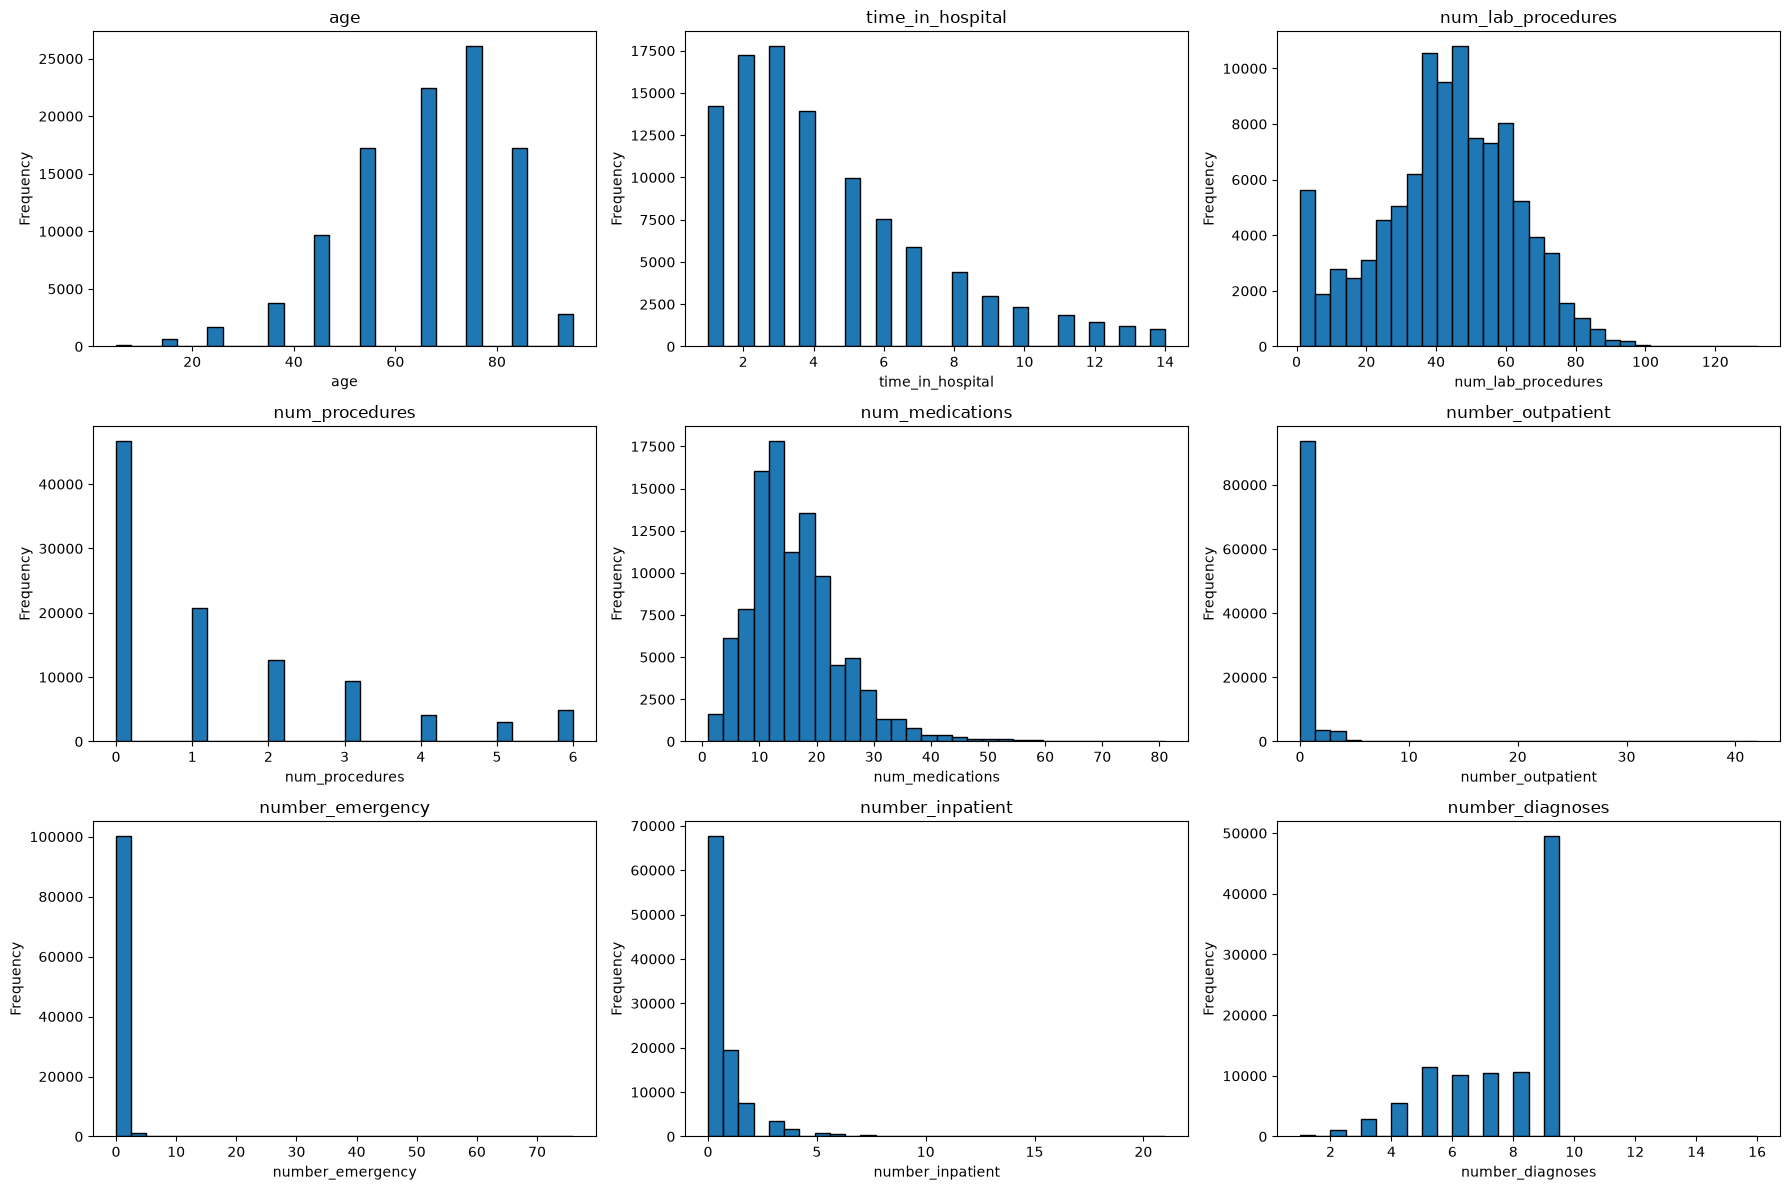

In [177]:
# ============================================================
# Distribution Analysis of Numerical Features
# ============================================================

# Import the plotting library.
import matplotlib.pyplot as plt

# Create a figure large enough to display all histograms.
plt.figure(figsize=(18, 12))

# Loop through every numerical feature.
for index, feature in enumerate(numerical_features, start=1):

    # Create a subplot for the current feature.
    plt.subplot(3, 3, index)

    # Plot the histogram.
    plt.hist(
        df[feature],
        bins=30,
        edgecolor="black"
    )
    # Set the subplot title.
    plt.title(feature)

    # Label the x-axis.
    plt.xlabel(feature)

    # Label the y-axis.
    plt.ylabel("Frequency")
# Automatically adjust spacing between subplots.
plt.tight_layout()

# Display all histograms.
plt.show()

### Distribution Analysis Results

The histograms show that the numerical features have different distribution patterns. Most features have a **single clear peak**, but several are **positively skewed**, especially **`number_outpatient`**, **`number_emergency`**, and **`number_inpatient`**, where most patients have few or no previous hospital visits.

The **`time_in_hospital`** and **`num_medications`** features are also right-skewed, showing that shorter hospital stays and moderate medication counts are more common. In contrast, **`num_lab_procedures`** has a more balanced distribution, while **`age`** is mainly concentrated between 55 and 85 years.

Overall, the histograms do not show any unusual gaps or unexpected patterns. The distributions appear consistent with the clinical nature of the dataset and provide a better understanding of the numerical features before model development.

#### *Multivariate* plot

means "more than one variable." These plots help you explore relationships between two or more features in your data. They can show you things like:  
- Do two features rise or fall together (correlation)?  
- Are there patterns that depend on more than one factor?  

Common univariate plots include:  

*Correlation matrix plot* shows how strongly each pair of variables is related, using colours in a *heatmap* to represent the correlation coefficients.

Each cell in the matrix shows a value between -1 and 1:
- *1* means a perfect positive relationship (as one goes up, so does the other)  
- *-1* means a perfect negative relationship (as one goes up, the other goes down)  
- *0* means no clear relationship between the two

These plots help you:
- Quickly identify strong positive or negative relationships  
- Spot features that may be redundant (highly correlated)  
- Decide which variables might be useful in a model

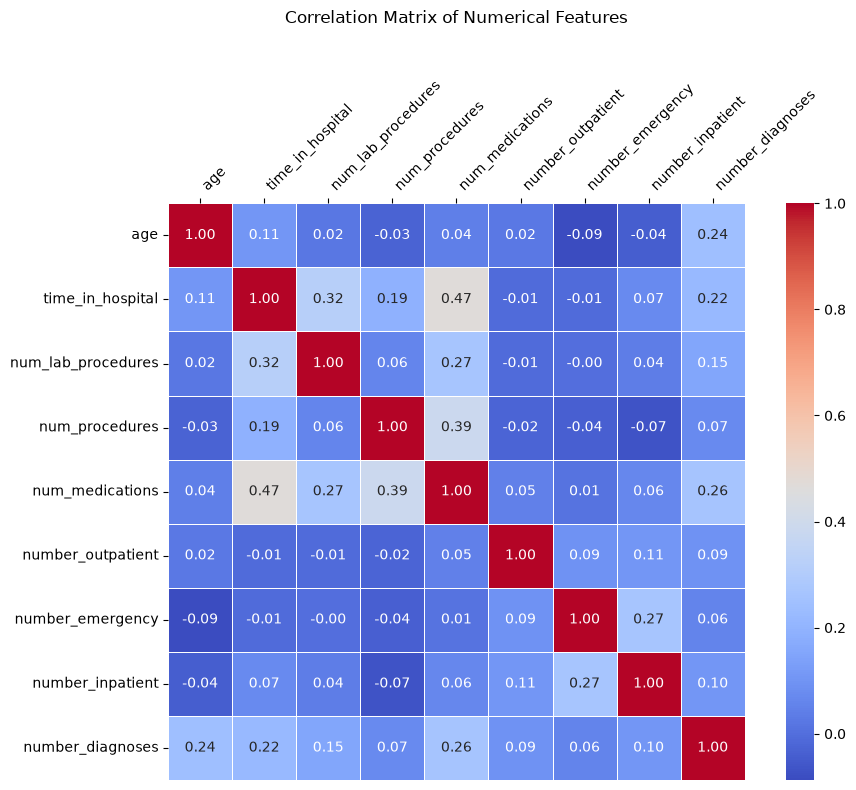

In [178]:
# =====================================================
# Correlation Matrix of Numerical Features
# =====================================================

# Import the libraries required for visualisation.
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df[numerical_features].corr(method="pearson")

# Create a figure for the heatmap.
plt.figure(figsize=(10, 8))

# Plot the correlation matrix as a heatmap.
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

# Display feature names at the top of the heatmap.
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Rotate axis labels for readability.
plt.xticks(rotation=45, ha="left")
plt.yticks(rotation=0)

# a title.
plt.title("Correlation Matrix of Numerical Features", pad=40)

# prevent overlapping labels.
plt.tight_layout()

# Display the heatmap.
plt.show()

### Correlation Analysis Results

The correlation matrix shows that most numerical features have **weak to moderate correlations**, with no strong positive or negative relationships. This suggests that each feature provides different information.

The strongest relationship is between **`time_in_hospital`** and **`num_medications`** *(r = 0.47)*, indicating that patients who stay in hospital longer generally receive more medications. Moderate positive correlations are also observed between **`num_procedures`** and **`num_medications`** *(r = 0.39)*, and between **`time_in_hospital`** and **`num_lab_procedures`** *(r = 0.32)*.

Overall, no pair of numerical features shows a strong correlation. Therefore, none of the numerical features appear to be redundant, and all will be retained for the next stages of preprocessing and feature selection.

## 5. Preparing Data for Machine Learning

Before training any models, the dataset must be prepared according to a standard machine learning workflow. This involves separating the predictor variables from the target variable, dividing the dataset into training and testing sets, and constructing a preprocessing pipeline that will transform the training and testing data consistently.

Performing these steps after feature engineering helps prevent data leakage and ensures that model evaluation reflects how the model would perform on previously unseen patient records.

### 5.1 Separating Features and Target Variable

Machine learning models learn relationships between the predictor variables (features) and the target variable.

The predictor variables are stored in **X**, while the target variable (`readmitted`) is stored separately in **y**. Separating the predictors from the target is a standard step before splitting the dataset into training and testing subsets.


In [179]:

# ==========================================
# Separate Features and Target Variable
# ==========================================

# Store all predictor variables.
X = df.drop(columns="readmitted")

# Store the target variable.
y = df["readmitted"]

# Display the dimensions.
print("Features (X):", X.shape)
print("Target (y):", y.shape)


Features (X): (101763, 36)
Target (y): (101763,)



### 5.2 Train-Test Split

The dataset is divided into separate training and testing subsets before any preprocessing or model training takes place.

The training dataset is used to learn the parameters required by the preprocessing pipeline and machine learning algorithms, while the testing dataset is reserved exclusively for evaluating the final model.

Separating the data before preprocessing prevents information from the testing dataset influencing the preprocessing steps, thereby reducing the risk of data leakage and providing a more realistic estimate of model performance on unseen data.

In this project, 80% of the data is used for training and the remaining 20% is reserved for testing.

A fixed random state of 42 was used to ensure that the train-test split is reproducible. Using the same random seed guarantees that the dataset is divided identically every time the notebook is executed, allowing experiments and results to be reproduced consistently. The specific value 42 has no statistical significance; any fixed integer would provide the same reproducibility.

Stratified sampling was applied using the target variable to preserve the original class distribution in both the training and testing datasets. Maintaining similar class proportions reduces sampling bias.


In [180]:

from sklearn.model_selection import train_test_split

# =====================================================
# Split Dataset into Training and Testing Sets
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)


Training Features : (81410, 36)
Testing Features  : (20353, 36)
Training Labels   : (81410,)
Testing Labels    : (20353,)


### 5.3 Identifying Feature Types

The predictor variables consist of both categorical and numerical data. Since different feature types require different preprocessing techniques, the features were already separated into categorical and numerical groups  in the above sections, we can directly use them here before constructing the preprocessing pipeline.

Separating the features in advance enables the preprocessing pipeline to automatically apply the appropriate transformation to each feature while maintaining a clean and reproducible machine learning workflow.


### 5.4 Numerical Feature Transformation

The numerical features in the dataset have different ranges and scales. These differences can affect machine learning algorithms that are sensitive to feature magnitude.

To place all numerical features on a comparable scale, **StandardScaler** will be used during preprocessing. StandardScaler centres each feature around a mean of `zero` and scales it to have a standard deviation of `one`. This helps ensure that no numerical feature has an unfair influence on the model simply because it contains larger values.

The numerical features have different ranges and therefore require scaling before model training. **StandardScaler** was selected because it standardises the numerical features while preserving their underlying distributions. Although several variables are highly skewed, these distributions represent genuine clinical patterns and do not require additional transformations.


### 5.5 Categorical Feature Encoding

The predictor variables include several categorical features that represent labels rather than numerical values. Since machine learning algorithms cannot process text directly, these features must be converted into a numerical format before model training.

All categorical predictor variables in this dataset are **nominal**, meaning that their categories have no natural ordering. Using numerical labels for these variables could introduce artificial relationships between categories that do not exist in the original data.

To preserve the independence of each category, **One-Hot Encoding** will be applied to all categorical predictor variables. This creates separate binary features for each category while avoiding any implied ordering between them.

The binary categorical features, including **`change`** and **`diabetesMed`**, will also be encoded using the same approach. Applying a single encoding method to all categorical predictor variables provides a consistent preprocessing pipeline and simplifies the machine learning workflow.

The target variable (**`readmitted`**) will be encoded separately into numerical class labels before model training. Since the target is not a predictor variable, it is not included in the preprocessing pipeline.

### 5.6 Building the Preprocessing Pipeline

The preprocessing steps defined in the previous sections are combined into a single preprocessing pipeline before model training.

A **ColumnTransformer** is used to apply different transformations to different feature types. Numerical features are standardised using **StandardScaler**, while categorical features are transformed using **OneHotEncoder**. The transformed features are then combined into a single dataset that can be used by the machine learning models.

Using a preprocessing pipeline ensures that the same transformations are applied consistently to both the training and testing datasets. It also helps prevent data leakage by fitting the preprocessing steps only on the training data before applying the same transformations to the testing data.

### Verifying Categorical Features

Before constructing the preprocessing pipeline, a final verification of the categorical features is performed.

This verification confirms that each categorical feature has the expected data type, contains the expected categories after data cleaning and feature engineering, and does not contain any unexpected or missing values that could affect the encoding process.

Performing these checks helps identify any remaining data quality issues before applying **One-Hot Encoding**, ensuring that the preprocessing pipeline is built using the final cleaned dataset.

In [ ]:
# ============================================================
# Verify Categorical Features Before Preprocessing
# ============================================================

# Create an empty list to store the summary information.
verification = []
# Loop through each categorical feature.
for feature in categorical_features:
    # Store the feature information.
    verification.append({
        # Feature name.
        "Feature": feature,
        # Data type of the feature.
        "Data Type": str(df[feature].dtype),

        # Number of unique categories.
        "Categories": df[feature].nunique(),
        # List all category values.
        "Category Values": ", ".join(
            sorted(map(str, df[feature].dropna().unique()))
        ),
        # Number of missing values.
        "Missing Values": df[feature].isnull().sum()

    })
# Convert the results into a DataFrame.
verification_df = pd.DataFrame(verification)

# Display the verification table.
display(verification_df)

,Feature,Data Type,Categories,Category Values,Missing Values
0,race,str,6,"AfricanAmerican, Asian, Caucasian, Hispanic, O...",0
1,gender,str,2,"Female, Male",0
2,admission_type_id,str,5,"Elective, Emergency, Other, Unknown, Urgent",0
3,discharge_disposition_id,str,8,"Continuing Care, Discharged Home Care, Dischar...",0
4,admission_source_id,str,6,"Birth, Emergency Room, Healthcare Transfer, Ot...",0
5,diag_1,str,19,"Blood Diseases, Circulatory System, Congenital...",0
6,diag_2,str,19,"Blood Diseases, Circulatory System, Congenital...",0
7,diag_3,str,19,"Blood Diseases, Circulatory System, Congenital...",0
8,max_glu_serum,str,4,">200, >300, None, Norm",0
9,A1Cresult,str,4,">7, >8, None, Norm",0


### Verification Results

The verification confirms that all categorical features are stored as string values and contain the expected categories following data cleaning and feature engineering. No unexpected categories or missing values remain that would affect the encoding process.

The categorical features are therefore ready to be transformed using **One-Hot Encoding** as part of the preprocessing pipeline.

In [ ]:
# ============================================================
# Build the Preprocessing Pipeline
# ============================================================

# Import the preprocessing classes.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Create the preprocessing pipeline.
#
# This pipeline defines how the data should be preprocessed
# before model training.
#
# At this stage, NO preprocessing is performed.
# The pipeline simply stores the preprocessing instructions.
#
# This cell can be executed multiple times without modifying
# the original dataset.
preprocessor = ColumnTransformer(

    # Define the preprocessing steps.
    transformers=[

        # ====================================================
        # Numerical Features
        # ====================================================
        #
        # Apply StandardScaler to all numerical features.
        #
        # StandardScaler:
        #   - Centres each feature around a mean of zero.
        #   - Scales each feature to have a standard deviation of one.
        #
        # This helps machine learning algorithms that are
        # sensitive to differences in feature scale.
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),

        # ====================================================
        # Categorical Features
        # ====================================================
        #
        # Apply One-Hot Encoding to all categorical features.
        #
        # drop="if_binary"
        #   - Removes one redundant column for binary features.
        #
        # handle_unknown="ignore"
        #   - Prevents errors if unseen categories appear in
        #     the testing data or future data.
        #
        # sparse_output=False
        #   - Returns a normal (dense) matrix instead of a
        #     sparse matrix, making the transformed data easier
        #     to inspect and debug.
        (
            "categorical",
            OneHotEncoder(
                drop="if_binary",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )

    ]
)

# Display the preprocessing pipeline.
#
# This only displays the preprocessing configuration.
# No scaling or encoding has been performed yet.
print(preprocessor)

ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                 ['age', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses']),
                                ('categorical',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['race', 'gender', 'admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'diag_1', 'diag_2',
                                  'diag_3', 'max_glu_serum', 'A1Cresult',
                                  'metformin', 'repaglini

### Summary

A preprocessing pipeline has been created using **ColumnTransformer**. The pipeline applies **StandardScaler** to the numerical features and **OneHotEncoder** to the categorical features. Defining the preprocessing steps in a single reusable object ensures that the same transformations are applied consistently throughout the machine learning workflow while reducing the risk of preprocessing errors.

### 5.7 Applying the Preprocessing Pipeline

After defining the preprocessing pipeline, it is applied to the training and testing datasets.

The preprocessing pipeline is **fitted only on the training data** using `fit_transform()`. During this step, **StandardScaler** learns the mean and standard deviation of each numerical feature, while **OneHotEncoder** learns the categories present in each categorical feature. The learned transformations are then applied to the training data.

The same preprocessing pipeline is subsequently applied to the testing data using `transform()`. Unlike `fit_transform()`, the `transform()` method does not learn any new information from the testing data. Instead, it applies the transformations learned from the training data.

Applying preprocessing in this way prevents data leakage and ensures that the testing dataset remains completely unseen during model training, providing a fair evaluation of model performance.

In [189]:
# ========================================================
# Apply the Preprocessing Pipeline
# ========================================================

# Fit the preprocessing pipeline using the training data
# and transform the training features.
#
# During this step:
#   - StandardScaler learns the mean and standard deviation
#     of each numerical feature.
#   - OneHotEncoder learns the categories for each
#     categorical feature.
#   - The learned transformations are then applied to
#     the training data.
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the learned preprocessing transformations to the
# testing data.
#
# IMPORTANT:
# The pipeline is NOT fitted again.
# It simply applies the transformations learned from the
# training data, preventing data leakage.
X_test_processed = preprocessor.transform(X_test)

# Display the shape of the processed datasets.
print("Processed Training Features :", X_train_processed.shape)
print("Processed Testing Features  :", X_test_processed.shape)

Processed Training Features : (81410, 176)
Processed Testing Features  : (20353, 176)


### Summary

The preprocessing pipeline was fitted using only the training dataset and then applied to both the training and testing datasets. Fitting the preprocessing steps exclusively on the training data prevents data leakage and ensures that the testing dataset remains unseen during model development. The processed datasets are now ready for machine learning model construction.

### 5.8 Verifying the Preprocessed Dataset

After applying the preprocessing pipeline, the transformed training and testing datasets are verified to ensure that the preprocessing has been performed correctly.

The verification confirms that the expected number of features has been produced after One-Hot Encoding, that the training and testing datasets have the correct dimensions, and that the transformed feature names have been generated successfully.

Performing these checks provides confidence that the processed datasets are ready for machine learning model construction.

In [192]:
# ============================================================
# Verify One-Hot Encoding Results
# ============================================================

encoding_summary = []

# Get the fitted encoder.
encoder = preprocessor.named_transformers_["categorical"]

# Loop through every categorical feature.
for feature, categories in zip(categorical_features, encoder.categories_):

    encoding_summary.append({

        "Feature": feature,
        "Categories Before": len(categories),
        "Columns After Encoding":
            len(categories) - 1 if len(categories) == 2 else len(categories)

    })

# Convert to a DataFrame.
encoding_summary = pd.DataFrame(encoding_summary)

# Display the summary.
display(encoding_summary)

,Feature,Categories Before,Columns After Encoding
0,race,6,6
1,gender,2,1
2,admission_type_id,5,5
3,discharge_disposition_id,8,8
4,admission_source_id,6,6
5,diag_1,19,19
6,diag_2,19,19
7,diag_3,19,19
8,max_glu_serum,4,4
9,A1Cresult,4,4
